In [1]:
import pandas as pd                 #data cleaning and manipulation
import numpy as np                  #numerical operations
import matplotlib.pyplot as plt     #data visualization
import seaborn as sns               #advanced data visualization


In [2]:
trade= pd.read_csv(r'C:\Users\Akshita\OneDrive\Desktop\Vietnam Project\Trade_Data_2013_2024.csv.csv', encoding='unicode_escape')
wdi= pd.read_csv(r'C:\Users\Akshita\OneDrive\Desktop\Vietnam Project\wdi_vietnam_2013_2024.csv.csv', encoding='unicode_escape')      
employment= pd.read_csv(r'C:\Users\Akshita\OneDrive\Desktop\Vietnam Project\ilostat_vietnam_employment_by_sector_per_thousand.csv.csv', encoding='unicode_escape')

In [3]:
employment.head()
employment.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ï»¿"ref_area.label"   33 non-null     object 
 1   source.label          33 non-null     object 
 2   indicator.label       33 non-null     object 
 3   classif1.label        33 non-null     object 
 4   classif2.label        33 non-null     object 
 5   time                  33 non-null     int64  
 6   obs_value             33 non-null     float64
 7   obs_status.label      0 non-null      float64
 8   note_classif.label    0 non-null      float64
 9   note_indicator.label  0 non-null      float64
 10  note_source.label     33 non-null     object 
dtypes: float64(4), int64(1), object(6)
memory usage: 3.0+ KB


## Employment Structure of Vietnam (Sectoral Analysis)

This section analyses Vietnam’s employment structure using ILOSTAT data.
The objective is to understand how labour is distributed across agriculture,
industry, and services, and how this structural composition explains
Vietnam’s trade patterns under classical trade theories such as
Heckscher–Ohlin and Comparative Advantage.


In [4]:
type(employment)

pandas.core.frame.DataFrame

In [5]:
employment.columns

Index(['ï»¿"ref_area.label"', 'source.label', 'indicator.label',
       'classif1.label', 'classif2.label', 'time', 'obs_value',
       'obs_status.label', 'note_classif.label', 'note_indicator.label',
       'note_source.label'],
      dtype='object')

In [6]:
employment.columns = employment.columns.str.strip()

#employment.columns now have no leading or trailing whitespace
# This ensures that column names are clean and can be accessed without issues related to extra spaces.
#str.strip is used to remove any leading or trailing whitespace from the column names.


In [7]:
employment = employment.rename(
    columns={
        'ï»¿"ref_area.label"': 'country',
        'classif1.label': 'sector',
        'time': 'year',
        'obs_value': 'employment_thousands'
    }
)

# renaming columns for better readability and ease of use

In [8]:
employment = employment[['country', 'sector', 'year', 'employment_thousands']]


In [9]:
employment.columns

Index(['country', 'sector', 'year', 'employment_thousands'], dtype='object')

In [10]:
employment = employment[employment['country'] == 'Viet Nam']


In [11]:
employment = employment.sort_values(
    ['year', 'sector']
).reset_index(drop=True)


In [12]:
employment = employment.drop_duplicates()
employment.duplicated().sum()



np.int64(0)

In [13]:
total_employment = (
    employment
    .groupby('year', as_index=False)['employment_thousands']
    .sum()
    .rename(columns={'employment_thousands': 'total_employment_thousands'})
)

#as index is used to keep year as a column instead of index
#groupby is used to aggregate data based on year 


In [14]:
employment = employment.merge(
    total_employment,
    on='year',
    how='left'
)

#on='year' indicates that the merge should be performed based on the 'year' column present in both DataFrames.
#how='left' specifies that we want to perform a left join, meaning all rows from the left DataFrame (employment) will be retained, and matching rows from the right DataFrame (total_employment) will be added where available. If there is no match, NaN values will be filled in for the columns from the right DataFrame.    


In [15]:
employment['employment_share_pct'] = (
    employment['employment_thousands'] /
    employment['total_employment_thousands'] * 100
)

# This calculation creates a new column 'employment_share_pct' that represents the percentage share of employment in each sector relative to the total employment for that year.
# It divides the employment in thousands for each sector by the total employment in thousands for that year and multiplies by 100 to convert it to a percentage.
# This metric helps to understand the distribution of employment across different sectors within the country for each year.
# It provides insights into which sectors are more dominant in terms of employment and how this distribution changes over time.
# This information can be valuable for economic analysis, policy-making, and understanding labor market dynamics.


In [16]:
employment.groupby('year')['employment_share_pct'].sum()

# The sum of employment_share_pct for each year should be approximately 100%, confirming that the shares are correctly calculated.
# Minor discrepancies may occur due to rounding errors.


year
2014    100.0
2015    100.0
2016    100.0
2017    100.0
2018    100.0
2019    100.0
2020    100.0
2021    100.0
2022    100.0
2023    100.0
2024    100.0
Name: employment_share_pct, dtype: float64

In [17]:
employment_pivot = (
    employment
    .pivot(index='year', columns='sector', values='employment_share_pct')
    .reset_index()
)

#reshaping the DataFrame to have years as rows and sectors as columns, with employment share percentages as values
#resetting the index to convert the index back into a column
#pivot function is used to reshape the DataFrame


In [18]:
employment_pivot.head(12)


sector,year,Economic activity (Broad sector): Agriculture,Economic activity (Broad sector): Industry,Economic activity (Broad sector): Services
0,2014,46.335763,21.446105,32.218131
1,2015,44.018451,22.743671,33.237878
2,2016,41.864907,24.762208,33.372885
3,2017,40.155441,25.776833,34.067726
4,2018,37.724118,26.704717,35.571165
5,2019,34.534971,29.588640,35.876389
6,2020,32.612388,31.069891,36.317722
7,2021,29.028326,33.125574,37.846100
8,2022,33.462371,30.682593,35.855035
9,2023,26.982708,33.467881,39.549411


In [77]:
employment_pivot.to_csv(
    "Vietnam_ILOSTAT_Employment_Structure_2013_2024.csv",
    index=False
)


### Conclusion: Employment Structure and Trade Implications

The sectoral employment data reveal a clear and sustained structural transformation in Vietnam’s labour market over the past decade. Between 2014 and 2024, the share of employment in agriculture declined sharply from over 46 per cent to nearly 26 per cent, indicating a steady movement of labour away from traditional, low-productivity activities. Over the same period, industry and services absorbed an increasing share of the workforce, with industrial employment rising to around one-third of total employment and services emerging as the largest employer by 2024.

This shift in employment structure is economically significant because it aligns closely with Vietnam’s observed trade patterns. The expansion of industrial employment reflects the country’s growing integration into global manufacturing value chains, particularly in labour-intensive sectors such as textiles, footwear, electronics assembly, and light manufacturing. From the perspective of the Heckscher–Ohlin theory, Vietnam’s trade specialisation is consistent with its factor endowments: a large, relatively low-cost labour force increasingly employed in manufacturing activities that generate export competitiveness.

At the same time, the rising share of services employment highlights an important limitation of classical trade models. While traditional theories emphasise goods trade driven by factor abundance, the growing role of services suggests that modern trade patterns are also shaped by urbanisation, domestic demand, logistics, and knowledge-based activities that classical frameworks do not fully capture. Overall, the employment evidence supports the relevance of classical trade theories in explaining Vietnam’s manufacturing-led export growth, while also indicating the need for broader frameworks to understand the evolving role of services in a globalised economy.


## Macroeconomic Context of Vietnam (WDI Analysis)

This section uses World Bank World Development Indicators (WDI) data
to analyse Vietnam’s macroeconomic environment between 2013 and 2024.
The objective is to understand how growth, income levels, inflation,
and openness support or constrain Vietnam’s trade patterns and the
applicability of classical trade theories.

In [19]:
wdi.shape
wdi.columns
wdi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Country Name   5 non-null      object 
 1   Country Code   3 non-null      object 
 2   Series Name    3 non-null      object 
 3   Series Code    3 non-null      object 
 4   2013 [YR2013]  3 non-null      float64
 5   2014 [YR2014]  3 non-null      float64
 6   2015 [YR2015]  3 non-null      float64
 7   2016 [YR2016]  3 non-null      float64
 8   2017 [YR2017]  3 non-null      float64
 9   2018 [YR2018]  3 non-null      float64
 10  2019 [YR2019]  3 non-null      float64
 11  2020 [YR2020]  3 non-null      float64
 12  2021 [YR2021]  3 non-null      float64
 13  2022 [YR2022]  3 non-null      float64
 14  2023 [YR2023]  3 non-null      float64
 15  2024 [YR2024]  3 non-null      float64
dtypes: float64(12), object(4)
memory usage: 1.1+ KB


In [20]:
wdi = wdi[wdi['Series Name'].notna()].copy()


In [21]:
wdi = wdi.rename(columns={
    'Country Name': 'country',
    'Series Name': 'indicator'
})


In [22]:
year_cols = [col for col in wdi.columns if '[YR' in col]
year_cols


['2013 [YR2013]',
 '2014 [YR2014]',
 '2015 [YR2015]',
 '2016 [YR2016]',
 '2017 [YR2017]',
 '2018 [YR2018]',
 '2019 [YR2019]',
 '2020 [YR2020]',
 '2021 [YR2021]',
 '2022 [YR2022]',
 '2023 [YR2023]',
 '2024 [YR2024]']

In [23]:
wdi_long = wdi.melt(
    id_vars=['country', 'indicator'],
    value_vars=year_cols,
    var_name='year',
    value_name='value'
)


In [24]:
wdi_long['year'] = wdi_long['year'].str.extract(r'(\d{4})').astype(int)
wdi_long['value'] = pd.to_numeric(wdi_long['value'], errors='coerce')


In [25]:
wdi_long = wdi_long.dropna(subset=['value'])
wdi_long.head()


,country,indicator,year,value
0,Viet Nam,GDP (current US$),2013,2.137088e+11
1,Viet Nam,Exports of goods and services (% of GDP),2013,6.680045e+01
2,Viet Nam,Imports of goods and services (% of GDP),2013,6.404591e+01
3,Viet Nam,GDP (current US$),2014,2.334515e+11
4,Viet Nam,Exports of goods and services (% of GDP),2014,6.959858e+01


In [26]:
gdp = wdi_long[wdi_long['indicator'] == 'GDP (current US$)']
exports = wdi_long[wdi_long['indicator'] == 'Exports of goods and services (% of GDP)']
imports = wdi_long[wdi_long['indicator'] == 'Imports of goods and services (% of GDP)']


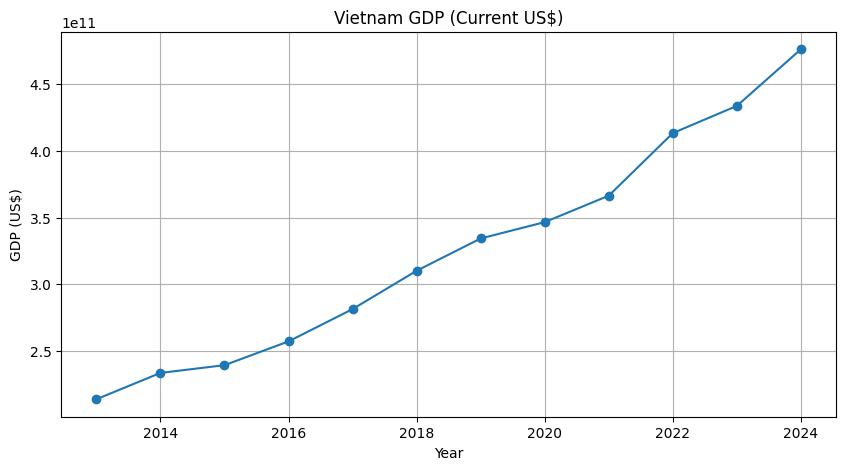

In [27]:
plt.figure(figsize=(10,5))
plt.plot(gdp['year'], gdp['value'], marker='o')
plt.title('Vietnam GDP (Current US$)')
plt.xlabel('Year')
plt.ylabel('GDP (US$)')
plt.grid(True)
plt.show()


The graph shows Vietnam’s GDP (current US$) from 2013 to 2024. GDP rises steadily from roughly USD 215 billion in 2013 to nearly USD 475 billion by 2024, more than doubling over the period.

This sustained expansion reflects strong structural growth driven by industrialization, export-led manufacturing, and rising domestic demand. Importantly, the GDP trajectory does not show a prolonged contraction during the pandemic period; instead, growth slows briefly around 2020 and accelerates sharply afterward. This underscores Vietnam’s ability to absorb external shocks while maintaining long-term economic momentum.

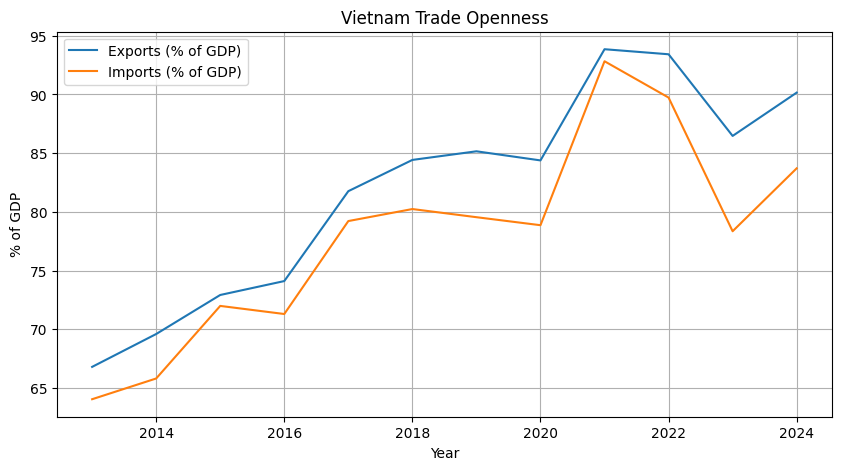

In [28]:
plt.figure(figsize=(10,5))
plt.plot(exports['year'], exports['value'], label='Exports (% of GDP)')
plt.plot(imports['year'], imports['value'], label='Imports (% of GDP)')
plt.title('Vietnam Trade Openness')
plt.xlabel('Year')
plt.ylabel('% of GDP')
plt.legend()
plt.grid(True)
plt.show()


The  graph illustrates Vietnam’s exports and imports as a percentage of GDP from 2013 to 2024. A clear upward trajectory is visible in both series, indicating a steady rise in trade openness over the decade.

Exports increased from approximately 67% of GDP in 2013 to above 90% by 2024, reflecting Vietnam’s deep integration into global value chains. Imports followed a similar pattern, rising from around 64% of GDP to nearly 84% in the same period. The parallel movement of exports and imports suggests that Vietnam’s export growth is closely linked to imported intermediate goods, consistent with its role as an assembly and manufacturing hub in East and Southeast Asia.

The temporary dip around 2020 coincides with the COVID-19 shock, yet the rapid rebound thereafter highlights the resilience of Vietnam’s trade sector. Overall, this pattern confirms Vietnam’s transformation into a highly open, trade-dependent economy.

In [29]:
wdi_summary = wdi_long.pivot_table(
    index='year',
    columns='indicator',
    values='value'
).reset_index()

wdi_summary.head()


indicator,year,Exports of goods and services (% of GDP),GDP (current US$),Imports of goods and services (% of GDP)
0,2013,66.800446,2.137088e+11,64.045909
1,2014,69.598576,2.334515e+11,65.811946
2,2015,72.922852,2.392583e+11,71.991376
3,2016,74.107286,2.570960e+11,71.302222
4,2017,81.762522,2.813536e+11,79.217562


In [78]:
wdi_summary['GDP_Billion_USD'] = wdi_summary['GDP (current US$)'] / 1_000_000_000


In [79]:
wdi_summary['GDP_Billion_USD'] = wdi_summary['GDP_Billion_USD'].round(2)


In [80]:
wdi_summary[['year', 'GDP_Billion_USD']].head()


indicator,year,GDP_Billion_USD
0,2013,213.71
1,2014,233.45
2,2015,239.26
3,2016,257.10
4,2017,281.35


In [81]:
wdi_summary = wdi_summary.drop(columns=['GDP (current US$)'])


In [82]:
wdi_summary.to_csv(
    "Vietnam_WDI_Macroeconomic_Indicators_Billions.csv",
    index=False
)


In [30]:
exports_only = exports[['year', 'value']].sort_values('year')

exports_only


,year,value
1,2013,66.800446
4,2014,69.598576
7,2015,72.922852
10,2016,74.107286
13,2017,81.762522
16,2018,84.423456
19,2019,85.157587
22,2020,84.381598
25,2021,93.850207
28,2022,93.420129


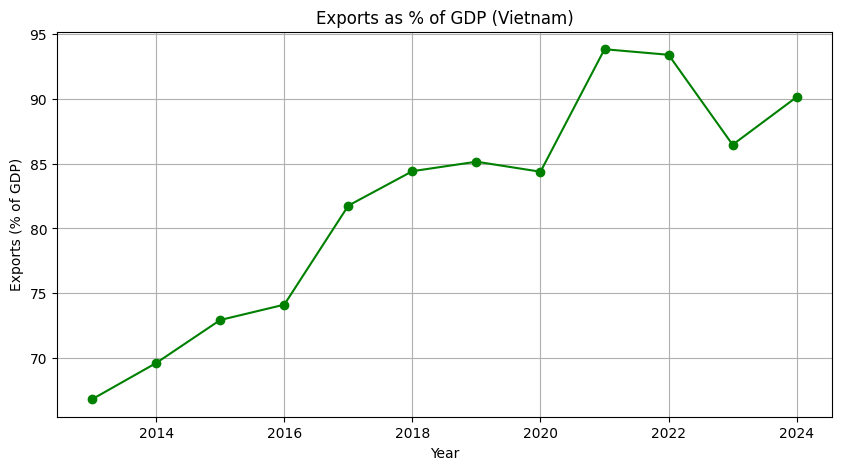

In [31]:
plt.figure(figsize=(10,5))
plt.plot(exports_only['year'], exports_only['value'], color='green', marker='o')
plt.title('Exports as % of GDP (Vietnam)')
plt.xlabel('Year')
plt.ylabel('Exports (% of GDP)')
plt.grid(True)
plt.show()


The graph isolates exports as a share of GDP, reinforcing Vietnam’s export-led growth model. Exports rise sharply from around 67% in 2013 to a peak of nearly 94% in 2021–2022.

This exceptionally high export-to-GDP ratio places Vietnam among the most export-oriented economies globally. The slight moderation after 2022 likely reflects global demand softening and supply-chain normalization rather than structural weakness. Overall, the graph confirms that external demand remains a central driver of Vietnam’s economic performance.

Vietnam’s GDP trend with a vertical marker indicating the COVID-19 shock in 2020. While growth momentum slows around this point, there is no visible collapse. Instead, GDP growth resumes strongly from 2021 onward.

This pattern highlights Vietnam’s effective macroeconomic management, diversified export base, and relatively swift recovery compared to many peer economies. The post-2020 acceleration also aligns with rising trade openness observed in the earlier graphs.

In [32]:
trade.shape
trade.head()
trade.info()


<class 'pandas.core.frame.DataFrame'>
Index: 6249 entries, C to C
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   typeCode                  6249 non-null   object 
 1   freqCode                  6249 non-null   int64  
 2   refPeriodId               6249 non-null   int64  
 3   refYear                   6249 non-null   int64  
 4   refMonth                  6249 non-null   int64  
 5   period                    6249 non-null   int64  
 6   reporterCode              6249 non-null   object 
 7   reporterISO               6249 non-null   object 
 8   reporterDesc              6249 non-null   object 
 9   flowCode                  6249 non-null   object 
 10  flowDesc                  6249 non-null   int64  
 11  partnerCode               6249 non-null   object 
 12  partnerISO                6249 non-null   object 
 13  partnerDesc               6249 non-null   int64  
 14  partner2Code    

In [33]:
pd.isnull(trade).sum()

typeCode                       0
freqCode                       0
refPeriodId                    0
refYear                        0
refMonth                       0
period                         0
reporterCode                   0
reporterISO                    0
reporterDesc                   0
flowCode                       0
flowDesc                       0
partnerCode                    0
partnerISO                     0
partnerDesc                    0
partner2Code                   0
partner2ISO                    0
partner2Desc                   0
classificationCode             0
classificationSearchCode       0
isOriginalClassification       0
cmdCode                        0
cmdDesc                        0
aggrLevel                      0
isLeaf                         0
customsCode                    0
customsDesc                    0
mosCode                        0
motCode                        0
motDesc                        0
qtyUnitCode                 6249
qtyUnitAbb

In [34]:
trade.columns = trade.columns.str.strip()

In [35]:
trade=trade.loc[:, [
    'refPeriodId',
    'flowCode',
    'partnerISO',
    'cmdCode',
    'fobvalue'
]]

#.loc is used to select specific columns from the DataFrame

In [36]:
trade=trade.rename(columns={
    'refPeriodId':'year', 
    'flowCode':'flow',
    'partnerISO':'partner',
    'cmdCode':'commodity',
    'fobvalue':'value'
})

In [37]:
trade.head()

,year,flow,partner,commodity,value
C,2013,Import,China,Animals; live,8250.0
C,2013,Import,China,Meat and edible meat offal,3800.0
C,2013,Import,China,"Fish and crustaceans, molluscs and other aquat...",22176586.0
C,2013,Import,China,"Beverages, spirits and vinegar",109499.0
C,2013,Import,China,Dairy produce; birds' eggs; natural honey; edi...,169265.0


In [38]:
print("Unique partners:")
print(trade['partner'].unique())
print("\nUnique flows:")
print(trade['flow']. unique())

#unique() is used to find all distinct values in a column

Unique partners:
['China' 'Japan' 'USA' "Dem. People's Rep. of Korea"]

Unique flows:
['Import' 'Export']


In [39]:
# Cell 6: Create comparison dataframe with values in billions
# First, filter Vietnam-Japan trade data
vietnam_japan = trade[trade['partner'] == 'Japan'].copy()
vietnam_imports_japan = vietnam_japan[vietnam_japan['flow'] == 'Import']
vietnam_exports_japan = vietnam_japan[vietnam_japan['flow'] == 'Export']

# Create comparison dataframe with values in billions
comparison_df = pd.DataFrame({
    'Imports from Japan': vietnam_imports_japan.groupby('commodity')['value'].sum() / 1e9,
    'Exports to Japan': vietnam_exports_japan.groupby('commodity')['value'].sum() / 1e9
}).fillna(0).sort_values('Imports from Japan', ascending=False)

print("\n" + "="*80)
print("VIETNAM-JAPAN IMPORTS & EXPORTS COMPARISON (In Billions USD)")
print("="*80)
print("\n")

# Format and display with proper spacing
pd.options.display.float_format = '{:.2f}'.format
print(comparison_df.to_string())


#pd.options.display.float_format is used to set the display format for floating-point numbers in pandas DataFrames.
# It ensures that when the DataFrame is printed, all floating-point numbers are displayed with two decimal places for better readability.
#comparison_df.to_string() is used to convert the DataFrame into a string representation for printing, preserving the formatting.
#.copy() is used to create a copy of the filtered DataFrame to avoid SettingWithCopyWarning in pandas.
#pd.dataFrame is used to create a new DataFrame for comparison of imports and exports.
#*80 is used to create a visual separator in the printed output for better readability.
#.fillna is used to replace NaN values with 0 in the comparison DataFrame to ensure accurate representation of trade values.
#pd.DataFrame is used to create a new DataFrame for organizing and comparing import and export values between Vietnam and Japan


VIETNAM-JAPAN IMPORTS & EXPORTS COMPARISON (In Billions USD)


                                                                                                                                                                                                                                           Imports from Japan  Exports to Japan
commodity                                                                                                                                                                                                                                                                      
Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles                                                                     61.69             45.94
Nuclear reactors, boilers, machinery and mechanical appliances; parts thereof                                           

In [40]:
# Cell 3 (Updated): Vietnam IMPORTS from Japan - in Billions
print("\n" + "="*80)
print("VIETNAM IMPORTS FROM JAPAN - BY COMMODITY AND VALUE (In Billions USD)")
print("="*80)

vietnam_imports_japan = vietnam_japan[vietnam_japan['flow'] == 'Import']
imports_by_commodity = (vietnam_imports_japan.groupby('commodity')['value'].sum() / 1e9).sort_values(ascending=False)

print("\nCommodity | Value (Billion USD)")
print("-" * 80)
for commodity, value in imports_by_commodity.items():
    print(f"{commodity:<65} ${value:>12.2f}B")

print("-" * 80)
print(f"{'TOTAL IMPORTS FROM JAPAN': <65} ${imports_by_commodity. sum():>12.2f}B")


VIETNAM IMPORTS FROM JAPAN - BY COMMODITY AND VALUE (In Billions USD)

Commodity | Value (Billion USD)
--------------------------------------------------------------------------------
Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles $       61.69B
Nuclear reactors, boilers, machinery and mechanical appliances; parts thereof $       24.72B
Iron and steel                                                    $       22.89B
Plastics and articles thereof                                     $       13.75B
Optical, photographic, cinematographic, measuring, checking, medical or surgical instruments and apparatus; parts and accessories $        8.84B
Vehicles; other than railway or tramway rolling stock, and parts and accessories thereof $        6.95B
Iron or steel articles                                            $        5.53B
Machinery and mechanical appliances

In [41]:
# Cell 4 (Updated): Vietnam EXPORTS to Japan - in Billions
print("\n" + "="*80)
print("VIETNAM EXPORTS TO JAPAN - BY COMMODITY AND VALUE (In Billions USD)")
print("="*80)

vietnam_exports_japan = vietnam_japan[vietnam_japan['flow'] == 'Export']
exports_by_commodity = (vietnam_exports_japan.groupby('commodity')['value'].sum() / 1e9).sort_values(ascending=False)

print("\nCommodity | Value (Billion USD)")
print("-" * 80)
for commodity, value in exports_by_commodity.items():
    print(f"{commodity: <65} ${value:>12.2f}B")

print("-" * 80)
print(f"{'TOTAL EXPORTS TO JAPAN':<65} ${exports_by_commodity.sum():>12.2f}B")


VIETNAM EXPORTS TO JAPAN - BY COMMODITY AND VALUE (In Billions USD)

Commodity | Value (Billion USD)
--------------------------------------------------------------------------------
Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles $       45.94B
Apparel and clothing accessories; not knitted or crocheted        $       17.32B
Apparel and clothing accessories; knitted or crocheted            $       16.24B
Fish and crustaceans, molluscs and other aquatic invertebrates    $        9.49B
Footwear; gaiters and the like; parts of such articles            $        8.73B
Wood and articles of wood; wood charcoal                          $        8.55B
Furniture; bedding, mattresses, mattress supports, cushions and similar stuffed furnishings; lamps and lighting fittings, n.e.c.; illuminated signs, illuminated name-plates and the like; prefabricated buildings $     

In [42]:
# Cell 5 (Updated): Summary comparison in Billions
print("\n" + "="*80)
print("VIETNAM-JAPAN TRADE SUMMARY (In Billions USD)")
print("="*80)

total_imports = imports_by_commodity.sum()
total_exports = exports_by_commodity.sum()
total_trade = total_imports + total_exports

print(f"\nTotal Imports from Japan: ${total_imports:.2f}B")
print(f"Total Exports to Japan:     ${total_exports:.2f}B")
print(f"Total Trade Value:        ${total_trade:.2f}B")
print(f"\nTrade Balance:  ${total_exports - total_imports:.2f}B")


VIETNAM-JAPAN TRADE SUMMARY (In Billions USD)

Total Imports from Japan: $196.99B
Total Exports to Japan:     $199.97B
Total Trade Value:        $396.96B

Trade Balance:  $2.98B


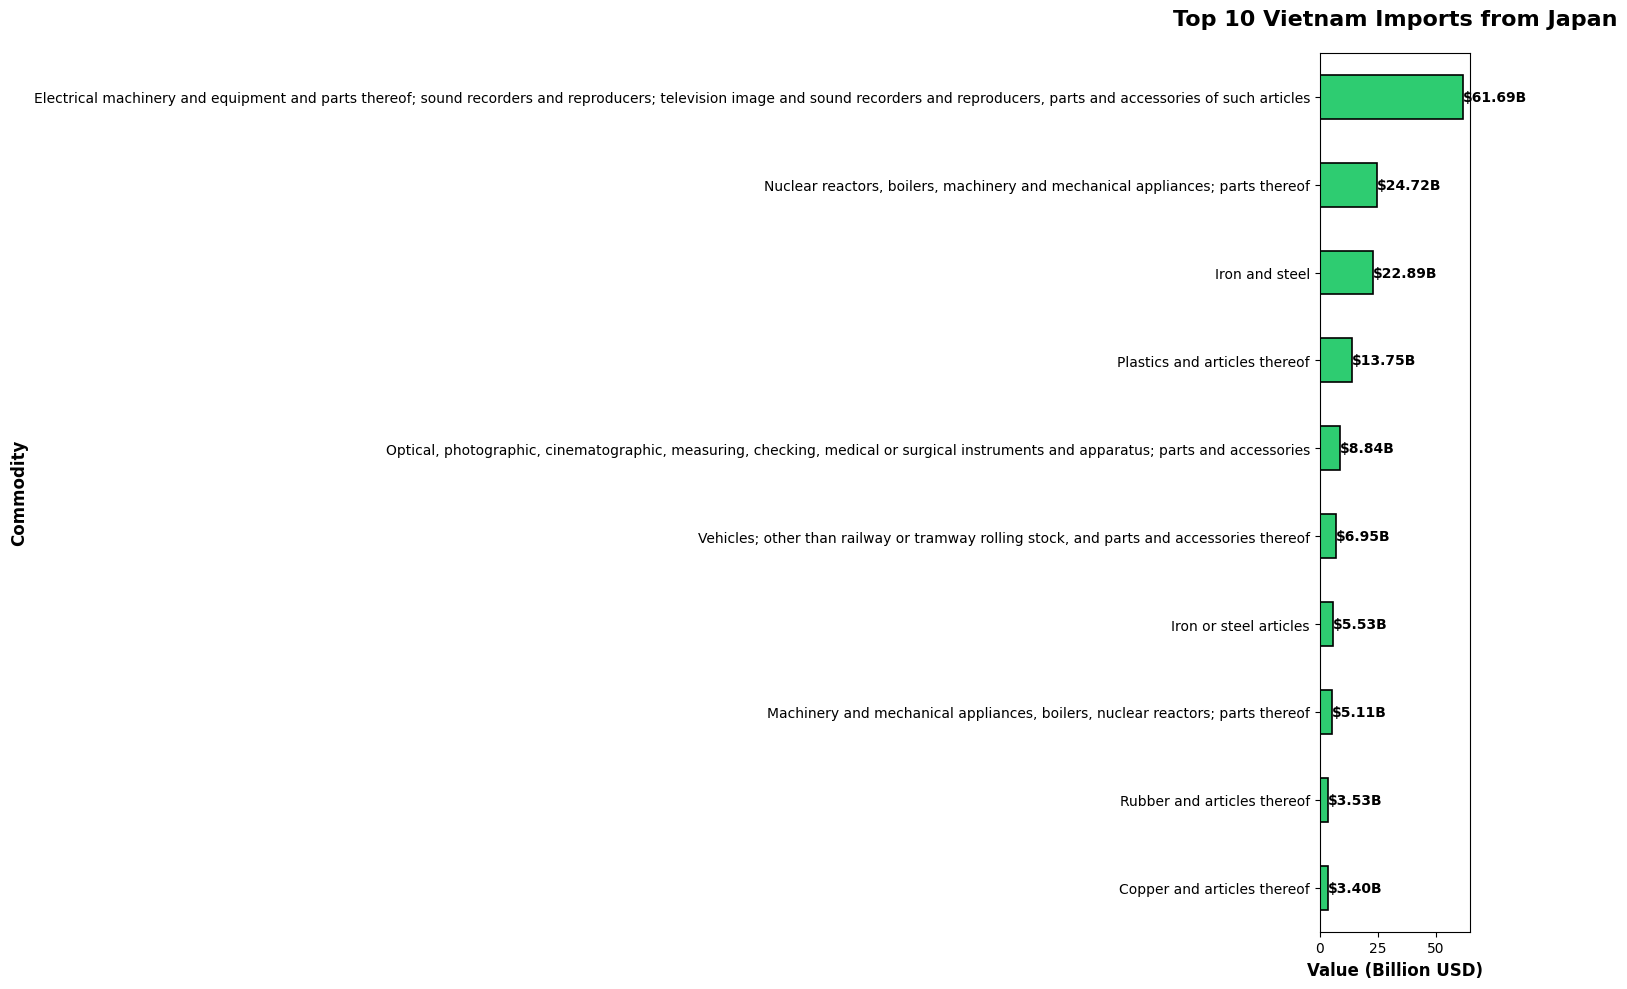

In [43]:
# Cell 8 (Updated): Visualization 1 - Top 10 Imports in Billions
fig, ax = plt.subplots(figsize=(15, 10))

top_imports = imports_by_commodity.head(10)
colors_import = ['#2ecc71'] * len(top_imports)

top_imports. plot(kind='barh', ax=ax, color=colors_import, edgecolor='black', linewidth=1.2)
ax.set_title('Top 10 Vietnam Imports from Japan', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Value (Billion USD)', fontsize=12, fontweight='bold')
ax.set_ylabel('Commodity', fontsize=12, fontweight='bold')
ax.invert_yaxis()

# Add value labels on bars
for i, v in enumerate(top_imports):
    ax.text(v + 0.05, i, f'${v:.2f}B', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\Akshita\AppData\Local\Temp\ipykernel_2604\1366801085.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


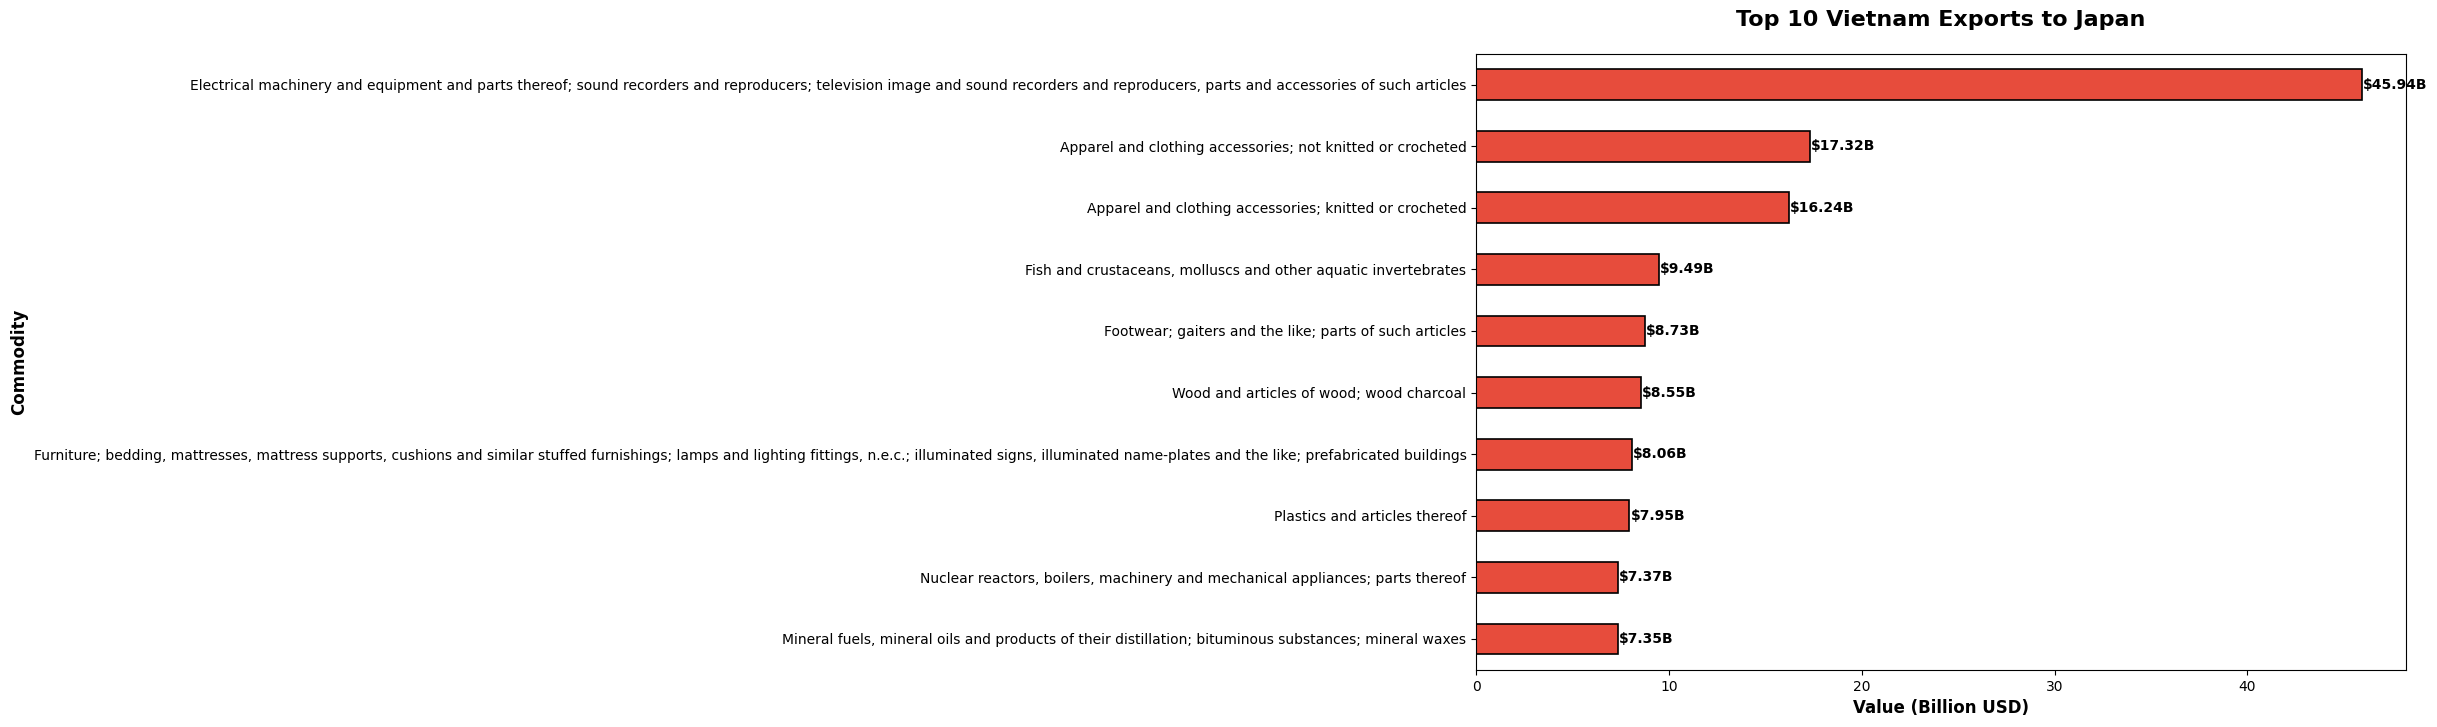

In [44]:
# Cell 9 (Updated): Visualization 2 - Top 10 Exports in Billions
fig, ax = plt.subplots(figsize=(12, 8))

top_exports = exports_by_commodity.head(10)
colors_export = ['#e74c3c'] * len(top_exports)

top_exports.plot(kind='barh', ax=ax, color=colors_export, edgecolor='black', linewidth=1.2)
ax.set_title('Top 10 Vietnam Exports to Japan', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Value (Billion USD)', fontsize=12, fontweight='bold')
ax.set_ylabel('Commodity', fontsize=12, fontweight='bold')
ax.invert_yaxis()

# Add value labels on bars
for i, v in enumerate(top_exports):
    ax.text(v + 0.05, i, f'${v:.2f}B', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

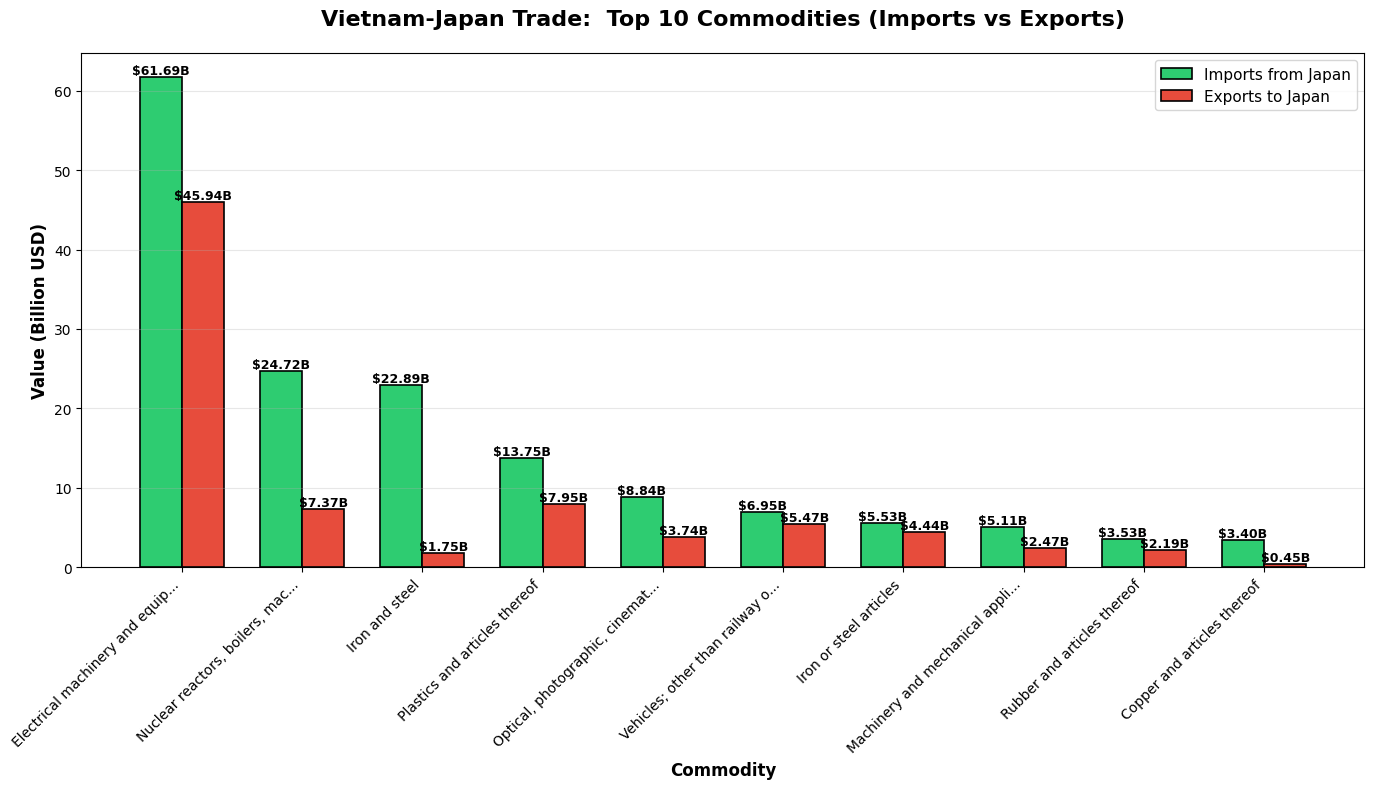

In [45]:
# Cell 10 (Updated): Visualization 3 - Side by Side in Billions
fig, ax = plt.subplots(figsize=(14, 8))

top_10_commodities = comparison_df.head(10)
x = range(len(top_10_commodities))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], top_10_commodities['Imports from Japan'], 
               width, label='Imports from Japan', color='#2ecc71', edgecolor='black', linewidth=1.2)
bars2 = ax.bar([i + width/2 for i in x], top_10_commodities['Exports to Japan'], 
               width, label='Exports to Japan', color='#e74c3c', edgecolor='black', linewidth=1.2)

ax.set_title('Vietnam-Japan Trade:  Top 10 Commodities (Imports vs Exports)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Commodity', fontsize=12, fontweight='bold')
ax.set_ylabel('Value (Billion USD)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([label[: 30] + '...' if len(label) > 30 else label 
                     for label in top_10_commodities. index], rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]: 
    for bar in bars: 
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:.2f}B', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

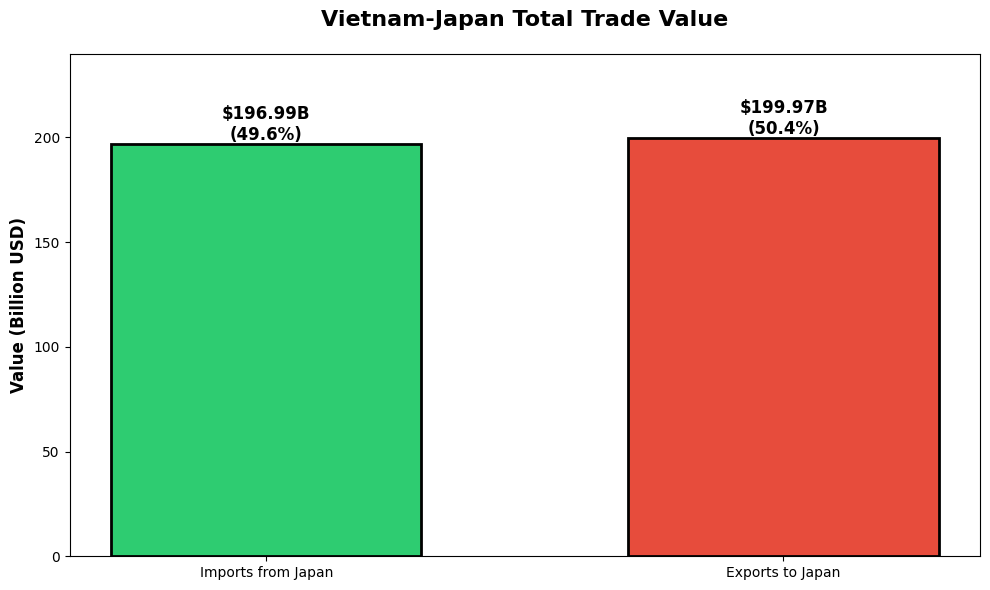

In [46]:
# Cell 12 (Updated): Visualization 5 - Total Trade Summary in Billions
fig, ax = plt.subplots(figsize=(10, 6))

trade_summary = pd.Series({
    'Imports from Japan': total_imports,
    'Exports to Japan':  total_exports
})

colors_summary = ['#2ecc71', '#e74c3c']
bars = ax.bar(trade_summary.index, trade_summary. values, color=colors_summary, 
              edgecolor='black', linewidth=2, width=0.6)

ax.set_title('Vietnam-Japan Total Trade Value', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Value (Billion USD)', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(trade_summary.values) * 1.2)

# Add value labels and percentage
for i, (bar, value) in enumerate(zip(bars, trade_summary.values)):
    height = bar.get_height()
    percentage = (value / total_trade) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${value:.2f}B\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

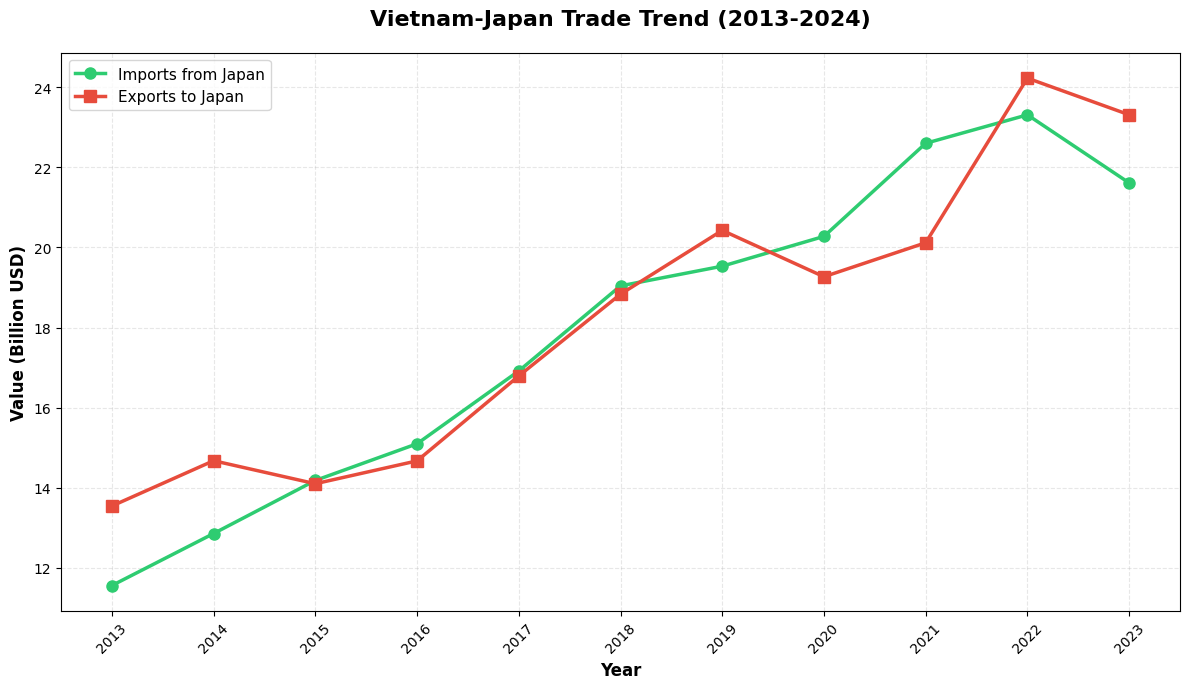

In [47]:
# Cell 13 (Updated): Visualization 6 - Year-wise Trend in Billions
fig, ax = plt.subplots(figsize=(12, 7))

# Group by year and convert to billions
yearly_imports = (vietnam_imports_japan.groupby('year')['value'].sum() / 1e9)
yearly_exports = (vietnam_exports_japan.groupby('year')['value'].sum() / 1e9)

ax.plot(yearly_imports.index, yearly_imports.values, marker='o', linewidth=2.5, 
    markersize=8, label='Imports from Japan', color='#2ecc71')
ax.plot(yearly_exports. index, yearly_exports.values, marker='s', linewidth=2.5, 
        markersize=8, label='Exports to Japan', color='#e74c3c')

ax.set_title('Vietnam-Japan Trade Trend (2013-2024)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Value (Billion USD)', fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(yearly_imports.index)
plt. xticks(rotation=45)

plt.tight_layout()
plt.show()

In [48]:
# Cell 15 (Updated): Summary Report in Billions
print("\n" + "="*80)
print("VIETNAM-JAPAN TRADE COMPLETE REPORT (In Billions USD)")
print("="*80)

print(f"\n📊 TOTAL TRADE VALUE: ${total_trade:.2f}B")
print(f"\n📥 Imports from Japan:   ${total_imports:.2f}B ({(total_imports/total_trade)*100:.1f}%)")
print(f"📤 Exports to Japan:     ${total_exports:.2f}B ({(total_exports/total_trade)*100:.1f}%)")
print(f"\n💱 Trade Balance:       ${total_exports - total_imports:.2f}B")

if total_exports > total_imports: 
    print(f"✅ Vietnam has a TRADE SURPLUS with Japan")
else:
    print(f"❌ Vietnam has a TRADE DEFICIT with Japan")

print(f"\n📈 Number of Import Commodities: {len(imports_by_commodity)}")
print(f"📈 Number of Export Commodities: {len(exports_by_commodity)}")

print(f"\n🏆 Top 3 Import Commodities:")
for i, (commodity, value) in enumerate(imports_by_commodity.head(3).items(), 1):
    print(f"   {i}. {commodity}:  ${value:.2f}B")

print(f"\n🏆 Top 3 Export Commodities:")
for i, (commodity, value) in enumerate(exports_by_commodity.head(3).items(), 1):
    print(f"   {i}. {commodity}: ${value:.2f}B")


VIETNAM-JAPAN TRADE COMPLETE REPORT (In Billions USD)

📊 TOTAL TRADE VALUE: $396.96B

📥 Imports from Japan:   $196.99B (49.6%)
📤 Exports to Japan:     $199.97B (50.4%)

💱 Trade Balance:       $2.98B
✅ Vietnam has a TRADE SURPLUS with Japan

📈 Number of Import Commodities: 102
📈 Number of Export Commodities: 101

🏆 Top 3 Import Commodities:
   1. Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles:  $61.69B
   2. Nuclear reactors, boilers, machinery and mechanical appliances; parts thereof:  $24.72B
   3. Iron and steel:  $22.89B

🏆 Top 3 Export Commodities:
   1. Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles: $45.94B
   2. Apparel and clothing accessories; not knitted or crocheted: $17.32B
   3. Apparel and clothing accessories

In [49]:
# Cell 2: Filter Vietnam-USA trade
vietnam_usa = trade[trade['partner'] == 'USA']. copy()

print("="*80)
print("VIETNAM-USA TRADE ANALYSIS")
print("="*80)

print(f"\nTotal Vietnam-USA records: {len(vietnam_usa)}")
print(vietnam_usa.head())

VIETNAM-USA TRADE ANALYSIS

Total Vietnam-USA records: 2073
   year    flow partner                                          commodity  \
C  2013  Import     USA  Dairy produce; birds' eggs; natural honey; edi...   
C  2013  Import     USA  Products of the milling industry; malt, starch...   
C  2013  Import     USA                     Sugars and sugar confectionery   
C  2013  Import     USA  Preparations of cereals, flour, starch or milk...   
C  2013  Import     USA  Preparations of vegetables, fruit, nuts or oth...   

         value  
C 202185911.00  
C    731607.00  
C  27579022.00  
C   9133942.00  
C   6690630.00  


In [50]:
# Cell 3: Vietnam IMPORTS from USA - Commodity and Value (In Billions USD)
print("\n" + "="*80)
print("VIETNAM IMPORTS FROM USA - BY COMMODITY AND VALUE (In Billions USD)")
print("="*80)

vietnam_imports_usa = vietnam_usa[vietnam_usa['flow'] == 'Import']
imports_by_commodity = (vietnam_imports_usa.groupby('commodity')['value'].sum() / 1e9).sort_values(ascending=False)

print("\nCommodity | Value (Billion USD)")
print("-" * 80)
for commodity, value in imports_by_commodity.items():
    print(f"{commodity: <65} ${value: >12.2f}B")

print("-" * 80)
print(f"{'TOTAL IMPORTS FROM USA':<65} ${imports_by_commodity. sum():>12.2f}B")


VIETNAM IMPORTS FROM USA - BY COMMODITY AND VALUE (In Billions USD)

Commodity | Value (Billion USD)
--------------------------------------------------------------------------------
Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles $       35.04B
Cotton                                                            $       11.50B
Plastics and articles thereof                                     $        6.52B
Food industries, residues and wastes thereof; prepared animal fodder $        6.11B
Nuclear reactors, boilers, machinery and mechanical appliances; parts thereof $        4.94B
Oil seeds and oleaginous fruits; miscellaneous grains, seeds and fruit, industrial or medicinal plants; straw and fodder $        4.53B
Optical, photographic, cinematographic, measuring, checking, medical or surgical instruments and apparatus; parts and accessories $        4.20B
Ir

In [51]:
# Cell 4: Vietnam EXPORTS to USA - Commodity and Value (In Billions USD)
print("\n" + "="*80)
print("VIETNAM EXPORTS TO USA - BY COMMODITY AND VALUE (In Billions USD)")
print("="*80)

vietnam_exports_usa = vietnam_usa[vietnam_usa['flow'] == 'Export']
exports_by_commodity = (vietnam_exports_usa.groupby('commodity')['value'].sum() / 1e9).sort_values(ascending=False)

print("\nCommodity | Value (Billion USD)")
print("-" * 80)
for commodity, value in exports_by_commodity. items():
    print(f"{commodity:<65} ${value:>12.2f}B")

print("-" * 80)
print(f"{'TOTAL EXPORTS TO USA':<65} ${exports_by_commodity.sum():>12.2f}B")


VIETNAM EXPORTS TO USA - BY COMMODITY AND VALUE (In Billions USD)

Commodity | Value (Billion USD)
--------------------------------------------------------------------------------
Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles $      187.15B
Apparel and clothing accessories; knitted or crocheted            $       82.67B
Footwear; gaiters and the like; parts of such articles            $       62.89B
Furniture; bedding, mattresses, mattress supports, cushions and similar stuffed furnishings; lamps and lighting fittings, n.e.c.; illuminated signs, illuminated name-plates and the like; prefabricated buildings $       60.62B
Apparel and clothing accessories; not knitted or crocheted        $       59.83B
Nuclear reactors, boilers, machinery and mechanical appliances; parts thereof $       31.75B
Machinery and mechanical appliances, boilers, nuclear reactors

In [52]:
# Cell 5: Summary comparison in Billions
print("\n" + "="*80)
print("VIETNAM-USA TRADE SUMMARY (In Billions USD)")
print("="*80)

total_imports = imports_by_commodity.sum()
total_exports = exports_by_commodity.sum()
total_trade = total_imports + total_exports

print(f"\nTotal Imports from USA: ${total_imports:.2f}B")
print(f"Total Exports to USA:     ${total_exports:.2f}B")
print(f"Total Trade Value:        ${total_trade:.2f}B")
print(f"\nTrade Balance:  ${total_exports - total_imports:.2f}B")


VIETNAM-USA TRADE SUMMARY (In Billions USD)

Total Imports from USA: $121.76B
Total Exports to USA:     $654.93B
Total Trade Value:        $776.69B

Trade Balance:  $533.18B


In [53]:
# Cell 6: Create comparison dataframe with values in billions
comparison_df = pd.DataFrame({
    'Imports from USA': vietnam_imports_usa. groupby('commodity')['value'].sum() / 1e9,
    'Exports to USA': vietnam_exports_usa.groupby('commodity')['value'].sum() / 1e9
}).fillna(0).sort_values('Imports from USA', ascending=False)

print("\n" + "="*80)
print("VIETNAM-USA IMPORTS & EXPORTS COMPARISON (In Billions USD)")
print("="*80)
print("\n")

# Format and display with proper spacing
pd.options.display.float_format = '{:.2f}'.format
print(comparison_df.to_string())


VIETNAM-USA IMPORTS & EXPORTS COMPARISON (In Billions USD)


                                                                                                                                                                                                                                           Imports from USA  Exports to USA
commodity                                                                                                                                                                                                                                                                  
Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles                                                                   35.04          187.15
Cotton                                                                                                                                

In [54]:
# Cell 7: Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

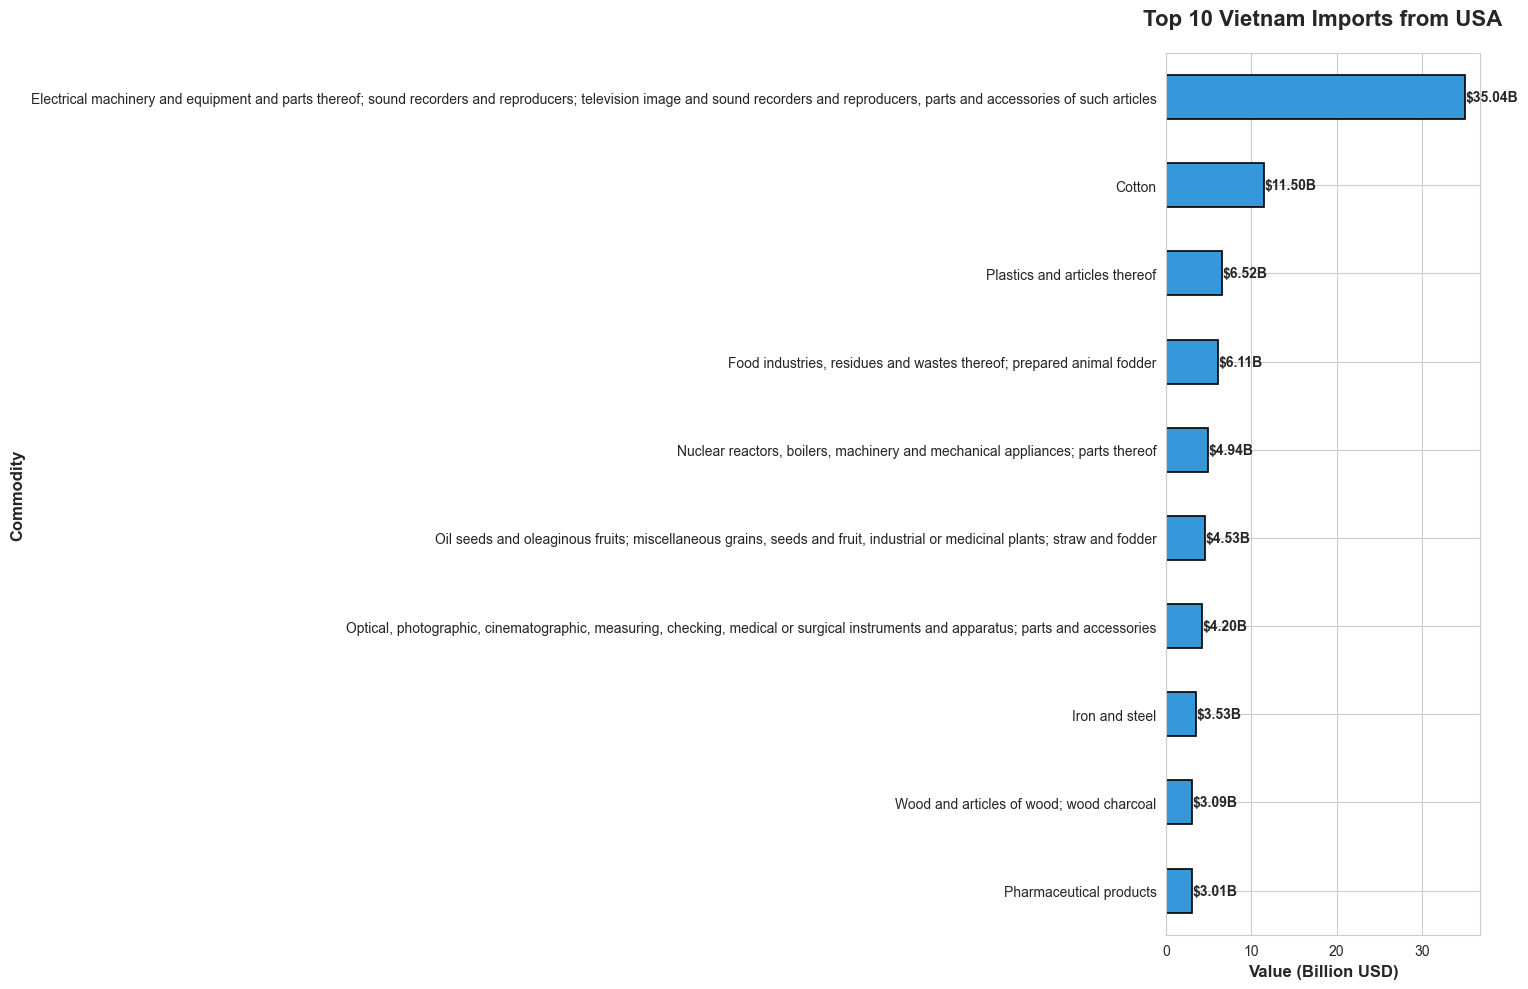

In [55]:
# Cell 8: Visualization 1 - Top 10 Imports from USA in Billions
fig, ax = plt.subplots(figsize=(15, 10))

top_imports = imports_by_commodity.head(10)
colors_import = ['#3498db'] * len(top_imports)

top_imports.plot(kind='barh', ax=ax, color=colors_import, edgecolor='black', linewidth=1.2)
ax.set_title('Top 10 Vietnam Imports from USA', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Value (Billion USD)', fontsize=12, fontweight='bold')
ax.set_ylabel('Commodity', fontsize=12, fontweight='bold')
ax.invert_yaxis()

# Add value labels on bars
for i, v in enumerate(top_imports):
    ax.text(v + 0.05, i, f'${v:.2f}B', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\Akshita\AppData\Local\Temp\ipykernel_2604\2860639431.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


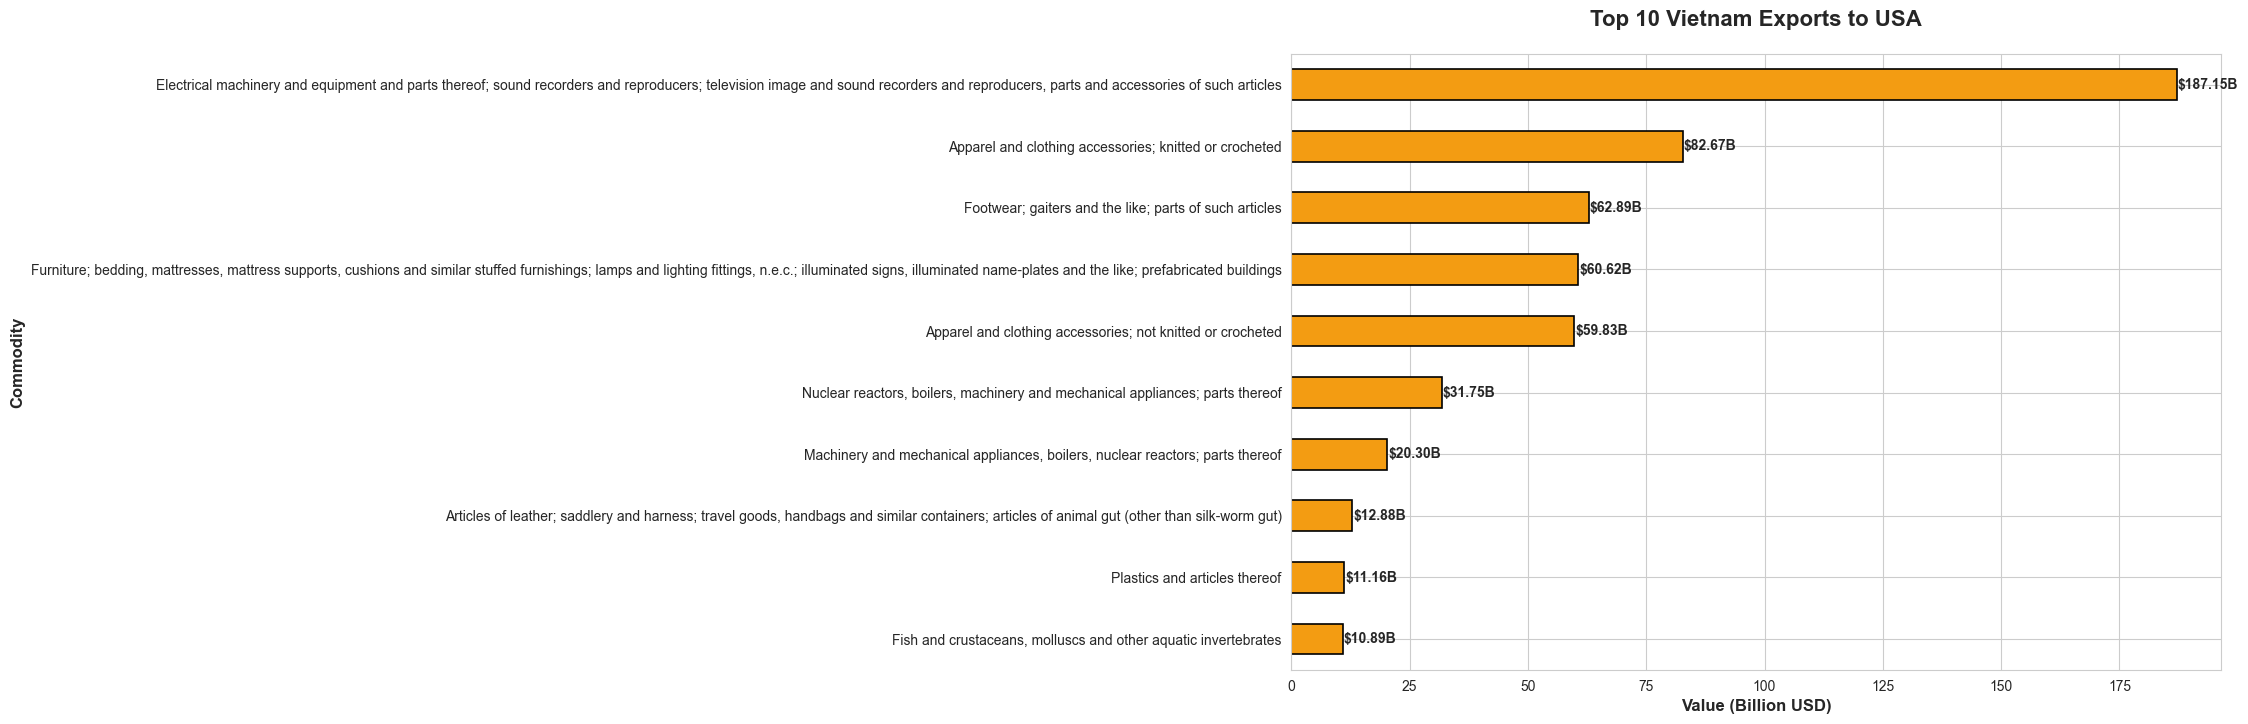

In [56]:
# Cell 9: Visualization 2 - Top 10 Exports to USA in Billions
fig, ax = plt.subplots(figsize=(12, 8))

top_exports = exports_by_commodity. head(10)
colors_export = ['#f39c12'] * len(top_exports)

top_exports.plot(kind='barh', ax=ax, color=colors_export, edgecolor='black', linewidth=1.2)
ax.set_title('Top 10 Vietnam Exports to USA', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Value (Billion USD)', fontsize=12, fontweight='bold')
ax.set_ylabel('Commodity', fontsize=12, fontweight='bold')
ax.invert_yaxis()

# Add value labels on bars
for i, v in enumerate(top_exports):
    ax.text(v + 0.2, i, f'${v:.2f}B', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

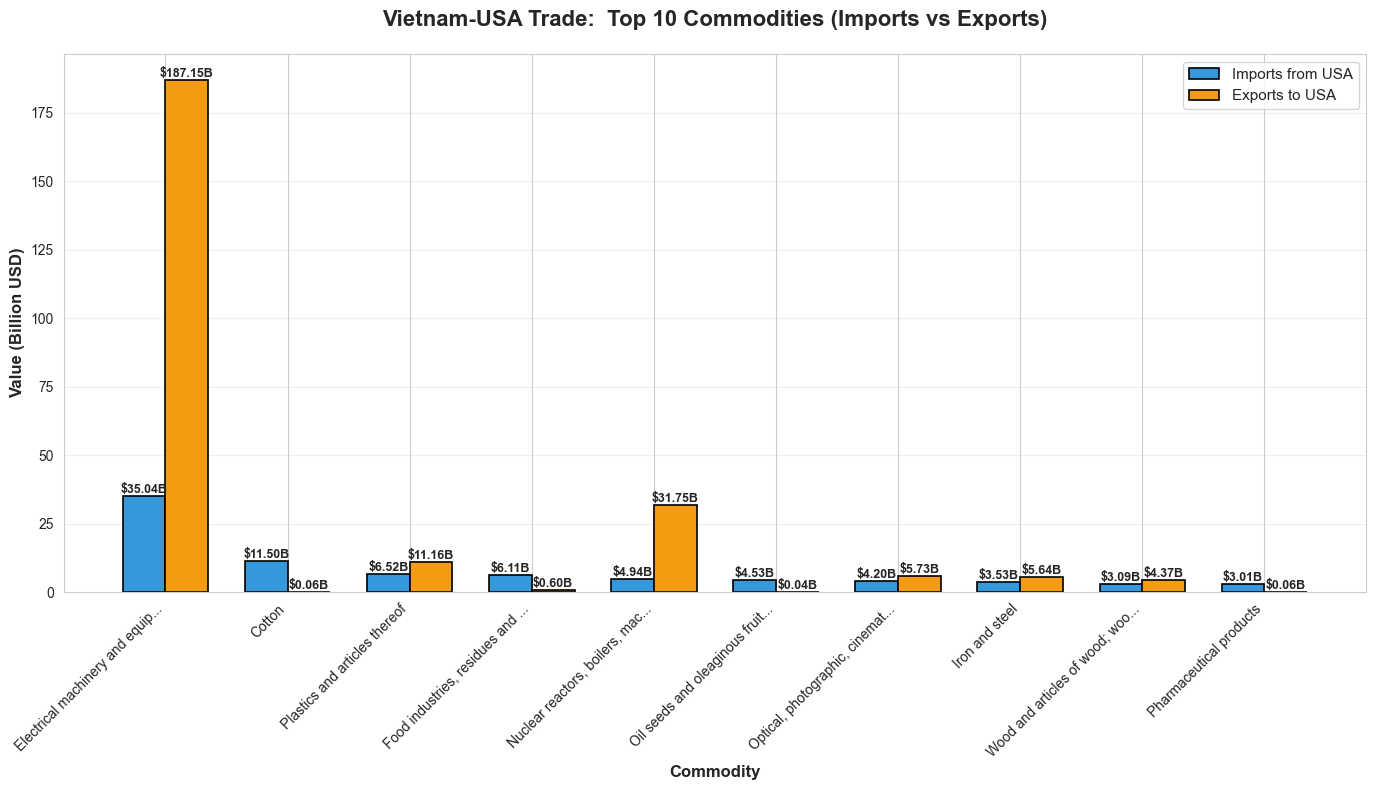

In [57]:
# Cell 10: Visualization 3 - Side by Side Comparison in Billions
fig, ax = plt.subplots(figsize=(14, 8))

top_10_commodities = comparison_df.head(10)
x = range(len(top_10_commodities))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], top_10_commodities['Imports from USA'], 
               width, label='Imports from USA', color='#3498db', edgecolor='black', linewidth=1.2)
bars2 = ax.bar([i + width/2 for i in x], top_10_commodities['Exports to USA'], 
               width, label='Exports to USA', color='#f39c12', edgecolor='black', linewidth=1.2)

ax.set_title('Vietnam-USA Trade:  Top 10 Commodities (Imports vs Exports)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Commodity', fontsize=12, fontweight='bold')
ax.set_ylabel('Value (Billion USD)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([label[: 30] + '...' if len(label) > 30 else label 
                     for label in top_10_commodities. index], rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]: 
    for bar in bars: 
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'${height:.2f}B', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

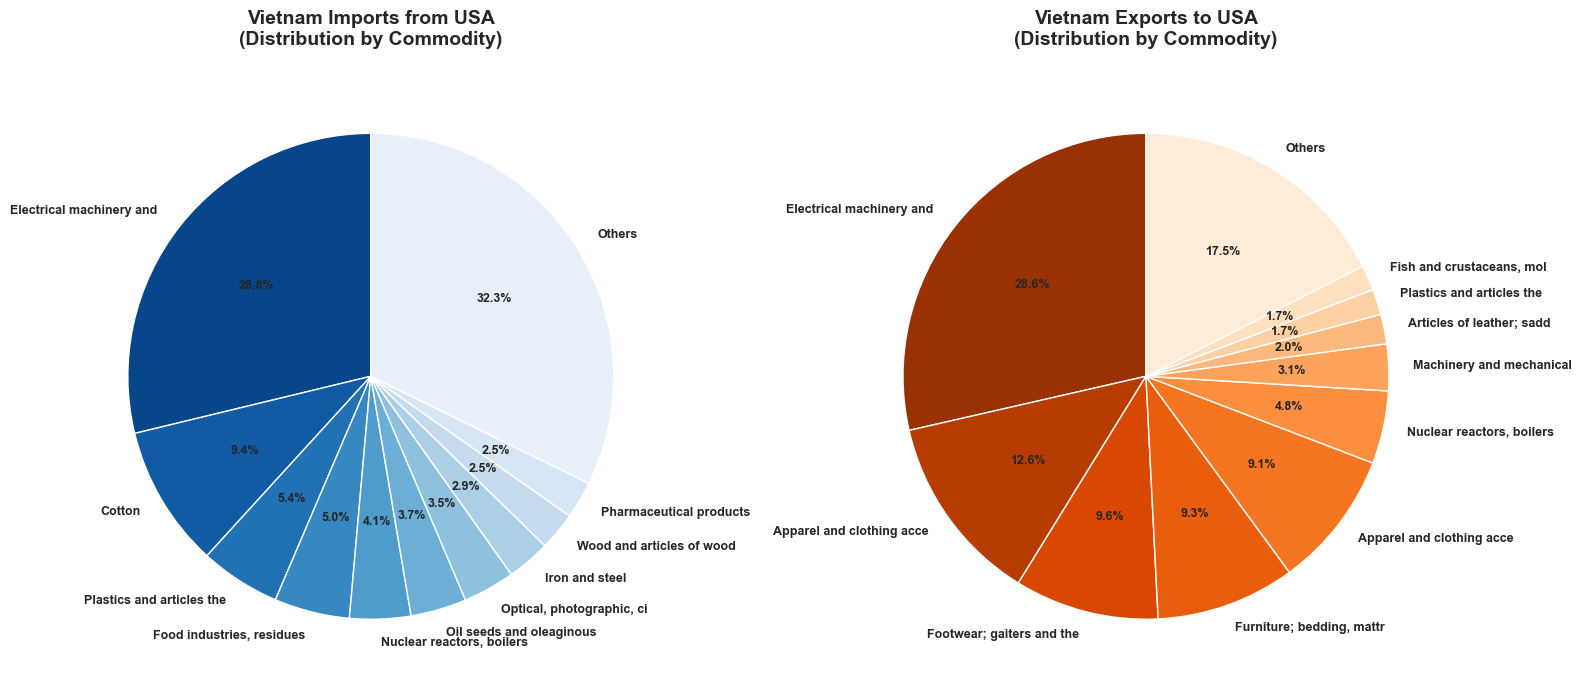

In [58]:
# Cell 11: Visualization 4 - Pie Charts (Imports vs Exports)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Imports Pie Chart
imports_top_10 = imports_by_commodity.head(10)
imports_other = imports_by_commodity[10: ]. sum()
if imports_other > 0:
    imports_data = pd.concat([imports_top_10, pd.Series({'Others': imports_other})])
else:
    imports_data = imports_top_10

colors1 = sns.color_palette('Blues_r', len(imports_data))
wedges1, texts1, autotexts1 = ax1.pie(imports_data, labels=[label[:25] for label in imports_data.index], 
                                        autopct='%1.1f%%', colors=colors1, startangle=90, 
                                        textprops={'fontsize': 9, 'fontweight': 'bold'})
ax1.set_title('Vietnam Imports from USA\n(Distribution by Commodity)', 
              fontsize=14, fontweight='bold', pad=20)

# Exports Pie Chart
exports_top_10 = exports_by_commodity.head(10)
exports_other = exports_by_commodity[10:].sum()
if exports_other > 0:
    exports_data = pd.concat([exports_top_10, pd.Series({'Others':  exports_other})])
else:
    exports_data = exports_top_10

colors2 = sns.color_palette('Oranges_r', len(exports_data))
wedges2, texts2, autotexts2 = ax2.pie(exports_data, labels=[label[:25] for label in exports_data.index], 
                                        autopct='%1.1f%%', colors=colors2, startangle=90,
                                        textprops={'fontsize': 9, 'fontweight': 'bold'})
ax2.set_title('Vietnam Exports to USA\n(Distribution by Commodity)', 
              fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

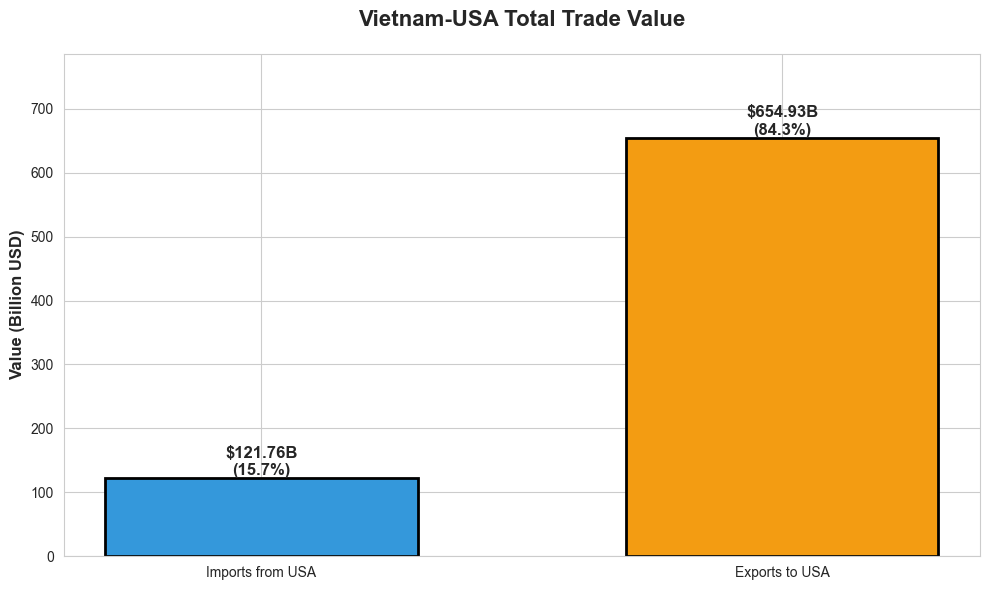

In [59]:
# Cell 12: Visualization 5 - Total Trade Summary in Billions
fig, ax = plt.subplots(figsize=(10, 6))

trade_summary = pd.Series({
    'Imports from USA': total_imports,
    'Exports to USA':  total_exports
})

colors_summary = ['#3498db', '#f39c12']
bars = ax.bar(trade_summary.index, trade_summary.values, color=colors_summary, 
              edgecolor='black', linewidth=2, width=0.6)

ax.set_title('Vietnam-USA Total Trade Value', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Value (Billion USD)', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(trade_summary.values) * 1.2)

# Add value labels and percentage
for i, (bar, value) in enumerate(zip(bars, trade_summary.values)):
    height = bar.get_height()
    percentage = (value / total_trade) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${value:.2f}B\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

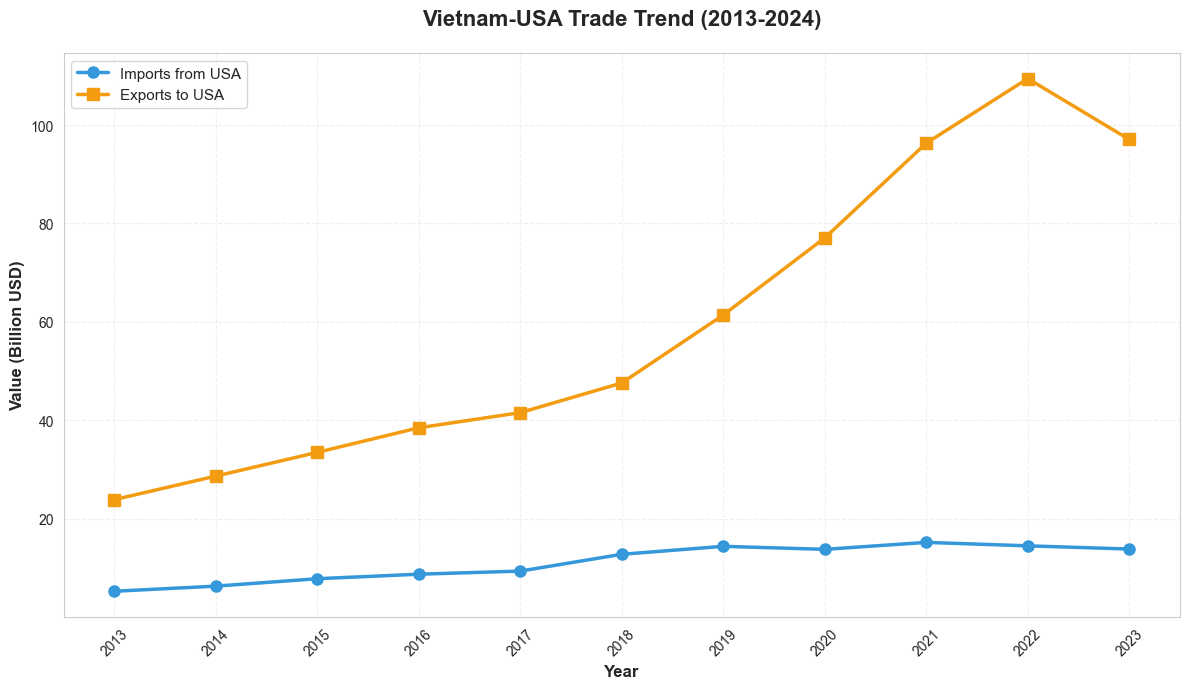

In [60]:
# Cell 13: Visualization 6 - Year-wise Trend in Billions
fig, ax = plt.subplots(figsize=(12, 7))

# Group by year and convert to billions
yearly_imports = (vietnam_imports_usa.groupby('year')['value'].sum() / 1e9)
yearly_exports = (vietnam_exports_usa.groupby('year')['value'].sum() / 1e9)

ax.plot(yearly_imports.index, yearly_imports.values, marker='o', linewidth=2.5, 
        markersize=8, label='Imports from USA', color='#3498db')
ax.plot(yearly_exports. index, yearly_exports.values, marker='s', linewidth=2.5, 
        markersize=8, label='Exports to USA', color='#f39c12')

ax.set_title('Vietnam-USA Trade Trend (2013-2024)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Value (Billion USD)', fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(yearly_imports.index)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [61]:
# Cell 15: Summary Report in Billions
print("\n" + "="*80)
print("VIETNAM-USA TRADE COMPLETE REPORT (In Billions USD)")
print("="*80)

print(f"\n📊 TOTAL TRADE VALUE: ${total_trade:.2f}B")
print(f"\n📥 Imports from USA:    ${total_imports:.2f}B ({(total_imports/total_trade)*100:.1f}%)")
print(f"📤 Exports to USA:     ${total_exports:.2f}B ({(total_exports/total_trade)*100:.1f}%)")
print(f"\n💱 Trade Balance:       ${total_exports - total_imports:.2f}B")

if total_exports > total_imports: 
    print(f"✅ Vietnam has a TRADE SURPLUS with USA")
else:
    print(f"❌ Vietnam has a TRADE DEFICIT with USA")

print(f"\n📈 Number of Import Commodities:  {len(imports_by_commodity)}")
print(f"📈 Number of Export Commodities:  {len(exports_by_commodity)}")

print(f"\n🏆 Top 3 Import Commodities:")
for i, (commodity, value) in enumerate(imports_by_commodity.head(3).items(), 1):
    print(f"   {i}. {commodity}: ${value:.2f}B")

print(f"\n🏆 Top 3 Export Commodities:")
for i, (commodity, value) in enumerate(exports_by_commodity.head(3).items(), 1):
    print(f"   {i}.  {commodity}: ${value:.2f}B")


VIETNAM-USA TRADE COMPLETE REPORT (In Billions USD)

📊 TOTAL TRADE VALUE: $776.69B

📥 Imports from USA:    $121.76B (15.7%)
📤 Exports to USA:     $654.93B (84.3%)

💱 Trade Balance:       $533.18B
✅ Vietnam has a TRADE SURPLUS with USA

📈 Number of Import Commodities:  102
📈 Number of Export Commodities:  102

🏆 Top 3 Import Commodities:
   1. Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles: $35.04B
   2. Cotton: $11.50B
   3. Plastics and articles thereof: $6.52B

🏆 Top 3 Export Commodities:
   1.  Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles: $187.15B
   2.  Apparel and clothing accessories; knitted or crocheted: $82.67B
   3.  Footwear; gaiters and the like; parts of such articles: $62.89B


In [62]:
# Cell 2: Filter Vietnam-China trade
vietnam_china = trade[trade['partner'] == 'China'].  copy()

print("="*80)
print("VIETNAM-CHINA TRADE ANALYSIS")
print("="*80)

print(f"\nTotal Vietnam-China records: {len(vietnam_china)}")
print(vietnam_china. head())

VIETNAM-CHINA TRADE ANALYSIS

Total Vietnam-China records: 2081
   year    flow partner                                          commodity  \
C  2013  Import   China                                      Animals; live   
C  2013  Import   China                         Meat and edible meat offal   
C  2013  Import   China  Fish and crustaceans, molluscs and other aquat...   
C  2013  Import   China                     Beverages, spirits and vinegar   
C  2013  Import   China  Dairy produce; birds' eggs; natural honey; edi...   

        value  
C     8250.00  
C     3800.00  
C 22176586.00  
C   109499.00  
C   169265.00  


In [63]:
# Cell 3: Vietnam IMPORTS from China - Commodity and Value (In Billions USD)
print("\n" + "="*80)
print("VIETNAM IMPORTS FROM China - BY COMMODITY AND VALUE (In Billions USD)")
print("="*80)

vietnam_imports_china = vietnam_china[vietnam_china['flow'] == 'Import']
imports_by_commodity = (vietnam_imports_china.groupby('commodity')['value'].sum() / 1e9).sort_values(ascending=False)

print("\nCommodity | Value (Billion USD)")
print("-" * 80)
for commodity, value in imports_by_commodity.items():
    print(f"{commodity: <65} ${value: >12.2f}B")

print("-" * 80)
print(f"{'TOTAL IMPORTS FROM CHINA':<65} ${imports_by_commodity.sum():>12.2f}B")


VIETNAM IMPORTS FROM China - BY COMMODITY AND VALUE (In Billions USD)

Commodity | Value (Billion USD)
--------------------------------------------------------------------------------
Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles $      293.36B
Nuclear reactors, boilers, machinery and mechanical appliances; parts thereof $       72.81B
Iron and steel                                                    $       45.82B
Plastics and articles thereof                                     $       42.10B
Fabrics; knitted or crocheted                                     $       29.38B
Machinery and mechanical appliances, boilers, nuclear reactors; parts thereof $       24.75B
Iron or steel articles                                            $       21.53B
Mineral fuels, mineral oils and products of their distillation; bituminous substances; mineral waxes $       1

In [64]:
# Cell 4: Vietnam EXPORTS to China - Commodity and Value (In Billions USD)
print("\n" + "="*80)
print("VIETNAM EXPORTS TO CHINA - BY COMMODITY AND VALUE (In Billions USD)")
print("="*80)

vietnam_exports_china = vietnam_china[vietnam_china['flow'] == 'Export']
exports_by_commodity = (vietnam_exports_china.groupby('commodity')['value'].sum() / 1e9).sort_values(ascending=False)

print("\nCommodity | Value (Billion USD)")
print("-" * 80)
for commodity, value in exports_by_commodity.items():
    print(f"{commodity: <65} ${value: >12.2f}B")

print("-" * 80)
print(f"{'TOTAL EXPORTS TO CHINA':<65} ${exports_by_commodity. sum():>12.2f}B")


VIETNAM EXPORTS TO CHINA - BY COMMODITY AND VALUE (In Billions USD)

Commodity | Value (Billion USD)
--------------------------------------------------------------------------------
Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles $      186.26B
Fruit and nuts, edible; peel of citrus fruit or melons            $       22.14B
Cotton                                                            $       20.41B
Rubber and articles thereof                                       $       17.73B
Footwear; gaiters and the like; parts of such articles            $       14.88B
Optical, photographic, cinematographic, measuring, checking, medical or surgical instruments and apparatus; parts and accessories $       13.43B
Wood and articles of wood; wood charcoal                          $       12.52B
Mineral fuels, mineral oils and products of their distillation; bitumino

In [65]:
# Cell 5: Summary comparison in Billions
print("\n" + "="*80)
print("VIETNAM-CHINA TRADE SUMMARY (In Billions USD)")
print("="*80)

total_imports = imports_by_commodity.sum()
total_exports = exports_by_commodity.sum()
total_trade = total_imports + total_exports

print(f"\nTotal Imports from China: ${total_imports:.2f}B")
print(f"Total Exports to China:     ${total_exports:.2f}B")
print(f"Total Trade Value:        ${total_trade:.2f}B")
print(f"\nTrade Balance:  ${total_exports - total_imports:.2f}B")


VIETNAM-CHINA TRADE SUMMARY (In Billions USD)

Total Imports from China: $802.00B
Total Exports to China:     $407.87B
Total Trade Value:        $1209.88B

Trade Balance:  $-394.13B


In [66]:
# Cell 7: Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

C:\Users\Akshita\AppData\Local\Temp\ipykernel_2604\3906730814.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


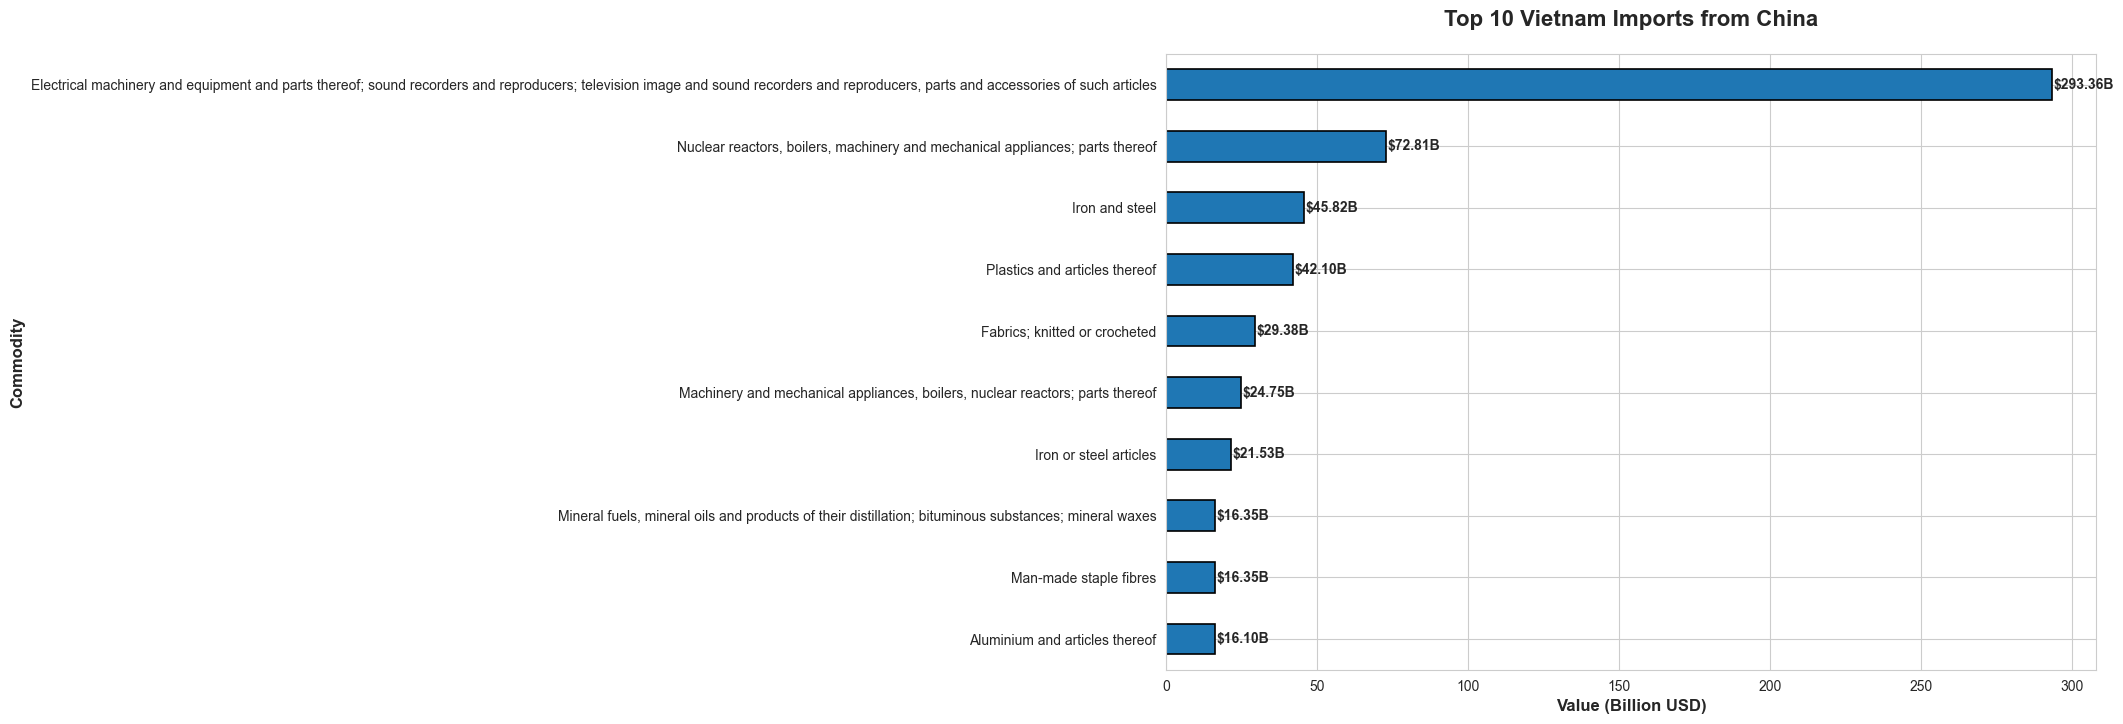

In [67]:
# Cell 8: Visualization 1 - Top 10 Imports from China in Billions
fig, ax = plt.subplots(figsize=(12, 8))

top_imports = imports_by_commodity.head(10)
colors_import = ['#1f77b4'] * len(top_imports)

top_imports.plot(kind='barh', ax=ax, color=colors_import, edgecolor='black', linewidth=1.2)
ax.set_title('Top 10 Vietnam Imports from China', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Value (Billion USD)', fontsize=12, fontweight='bold')
ax.set_ylabel('Commodity', fontsize=12, fontweight='bold')
ax.invert_yaxis()

# Add value labels on bars
for i, v in enumerate(top_imports):
    ax.text(v + 0.5, i, f'${v:.2f}B', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\Akshita\AppData\Local\Temp\ipykernel_2604\2297739639.py:17: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


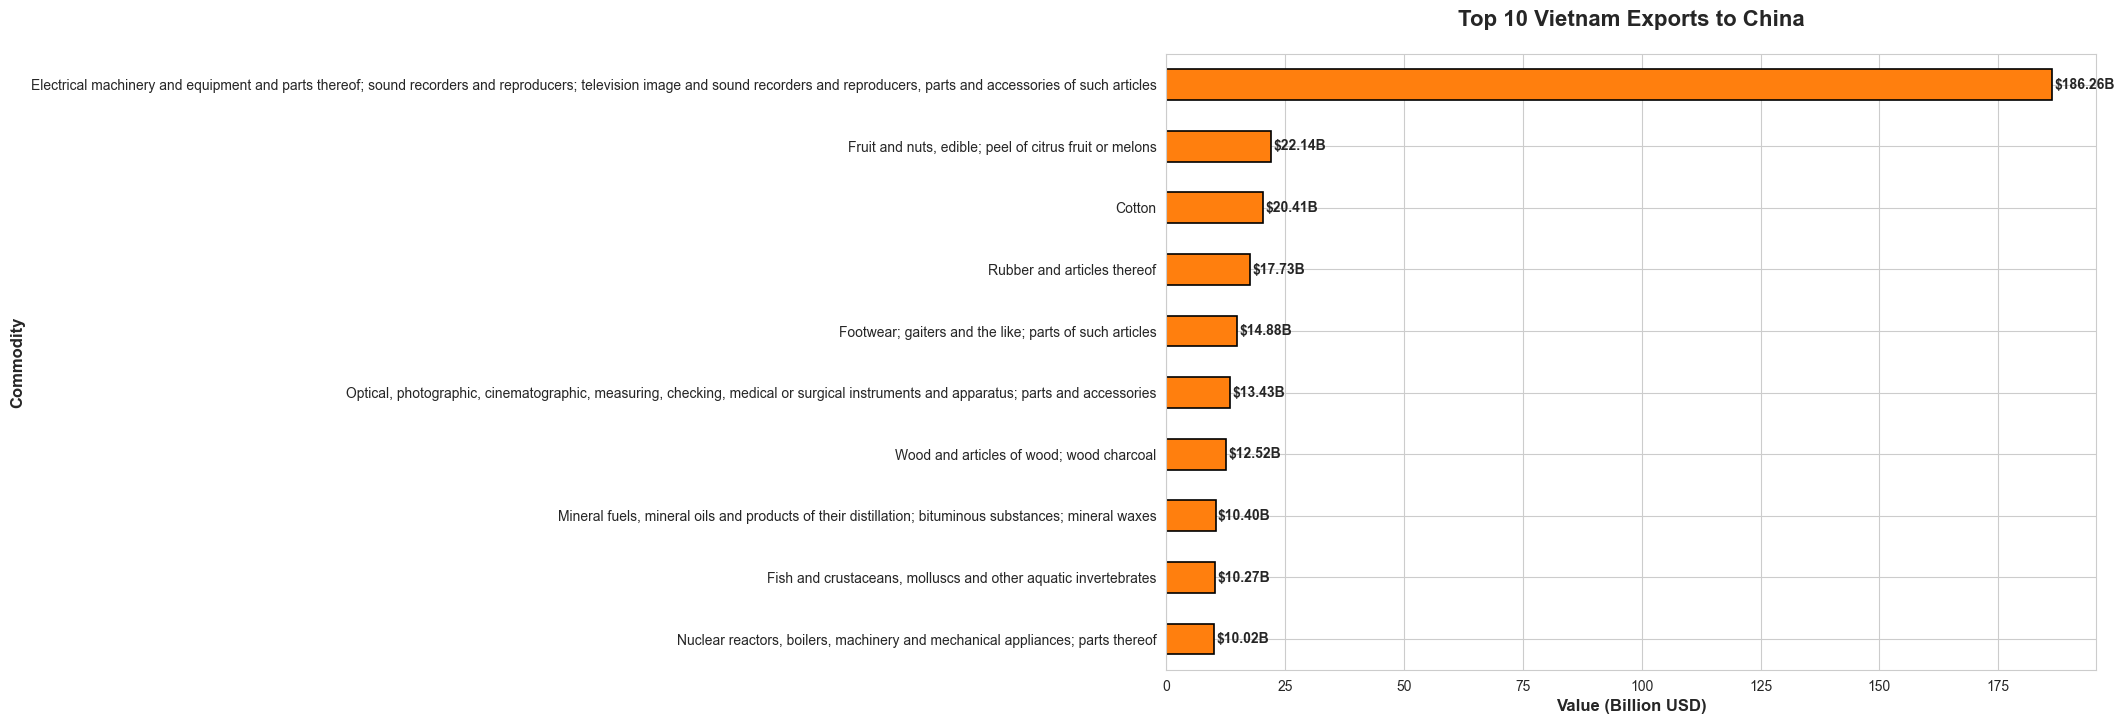

In [68]:
# Cell 9: Visualization 2 - Top 10 Exports to China in Billions
fig, ax = plt.subplots(figsize=(12, 8))

top_exports = exports_by_commodity.head(10)
colors_export = ['#ff7f0e'] * len(top_exports)

top_exports.plot(kind='barh', ax=ax, color=colors_export, edgecolor='black', linewidth=1.2)
ax.set_title('Top 10 Vietnam Exports to China', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Value (Billion USD)', fontsize=12, fontweight='bold')
ax.set_ylabel('Commodity', fontsize=12, fontweight='bold')
ax.invert_yaxis()

# Add value labels on bars
for i, v in enumerate(top_exports):
    ax.text(v + 0.5, i, f'${v:.2f}B', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

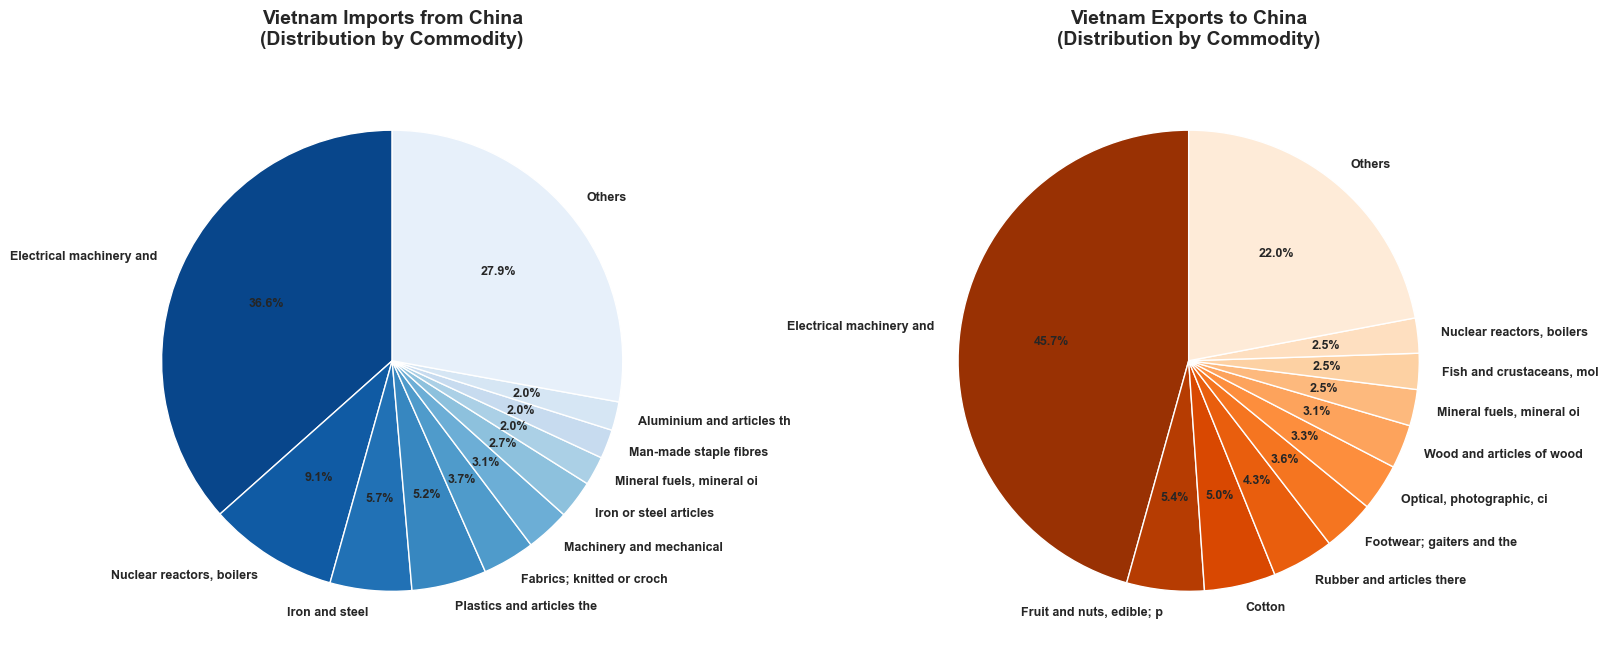

In [69]:
# Cell 11: Visualization 4 - Pie Charts (Imports vs Exports)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Imports Pie Chart
imports_top_10 = imports_by_commodity.head(10)
imports_other = imports_by_commodity[10: ].sum()
if imports_other > 0:
    imports_data = pd.concat([imports_top_10, pd.Series({'Others': imports_other})])
else:
    imports_data = imports_top_10

colors1 = sns.color_palette('Blues_r', len(imports_data))
wedges1, texts1, autotexts1 = ax1.pie(imports_data, labels=[label[:25] for label in imports_data.index], 
                                        autopct='%1.1f%%', colors=colors1, startangle=90, 
                                        textprops={'fontsize': 9, 'fontweight': 'bold'})
ax1.set_title('Vietnam Imports from China\n(Distribution by Commodity)', 
              fontsize=14, fontweight='bold', pad=20)

# Exports Pie Chart
exports_top_10 = exports_by_commodity.head(10)
exports_other = exports_by_commodity[10:].sum()
if exports_other > 0:
    exports_data = pd.concat([exports_top_10, pd.Series({'Others':  exports_other})])
else:
    exports_data = exports_top_10

colors2 = sns.color_palette('Oranges_r', len(exports_data))
wedges2, texts2, autotexts2 = ax2.pie(exports_data, labels=[label[:25] for label in exports_data.index], 
                                        autopct='%1.1f%%', colors=colors2, startangle=90,
                                        textprops={'fontsize': 9, 'fontweight': 'bold'})
ax2.set_title('Vietnam Exports to China\n(Distribution by Commodity)', 
              fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

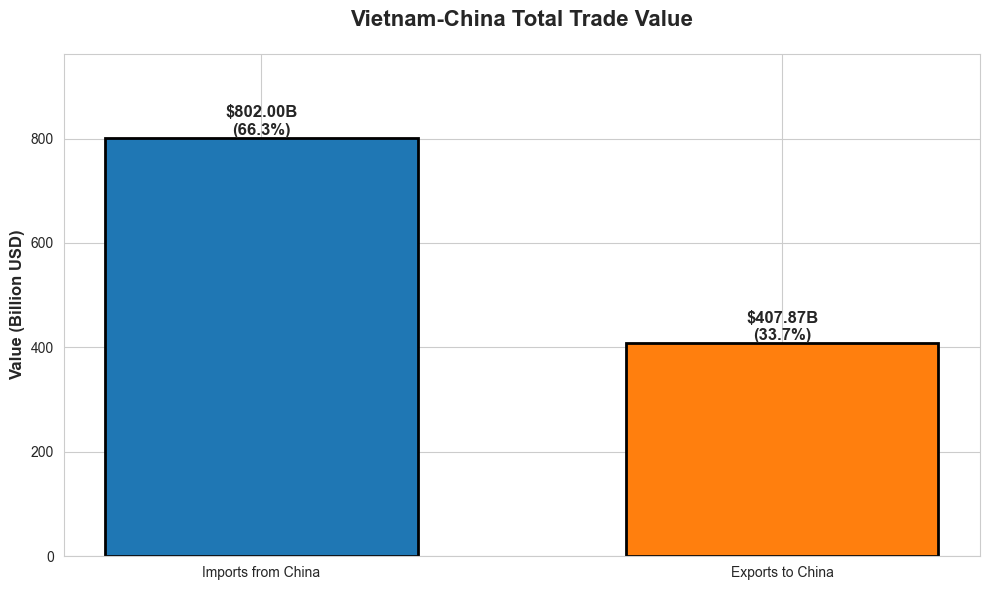

In [70]:
# Cell 12:  Visualization 5 - Total Trade Summary in Billions
fig, ax = plt.subplots(figsize=(10, 6))

trade_summary = pd.Series({
    'Imports from China': total_imports,
    'Exports to China':   total_exports
})

colors_summary = ['#1f77b4', '#ff7f0e']
bars = ax.bar(trade_summary.index, trade_summary.values, color=colors_summary, 
              edgecolor='black', linewidth=2, width=0.6)

ax.set_title('Vietnam-China Total Trade Value', fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel('Value (Billion USD)', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(trade_summary.values) * 1.2)

# Add value labels and percentage
for i, (bar, value) in enumerate(zip(bars, trade_summary.values)):
    height = bar.get_height()
    percentage = (value / total_trade) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${value:.2f}B\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

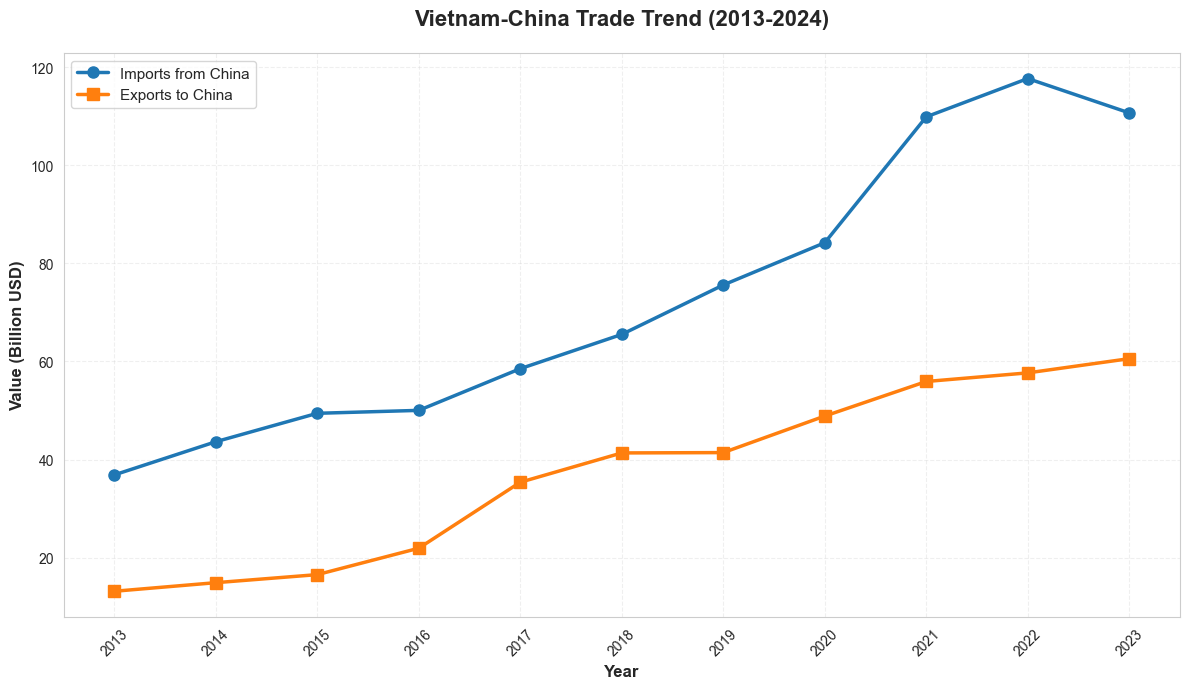

In [71]:
# Cell 13: Visualization 6 - Year-wise Trend in Billions
fig, ax = plt.subplots(figsize=(12, 7))

# Group by year and convert to billions
yearly_imports = (vietnam_imports_china.groupby('year')['value'].sum() / 1e9)
yearly_exports = (vietnam_exports_china.groupby('year')['value'].sum() / 1e9)

ax.plot(yearly_imports.index, yearly_imports.values, marker='o', linewidth=2.5, 
        markersize=8, label='Imports from China', color='#1f77b4')
ax.plot(yearly_exports.index, yearly_exports.values, marker='s', linewidth=2.5, 
        markersize=8, label='Exports to China', color='#ff7f0e')

ax.set_title('Vietnam-China Trade Trend (2013-2024)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Value (Billion USD)', fontsize=12, fontweight='bold')
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xticks(yearly_imports.index)
plt. xticks(rotation=45)

plt.tight_layout()
plt.show()

In [72]:
# Cell 15: Summary Report in Billions
print("\n" + "="*80)
print("VIETNAM-CHINA TRADE COMPLETE REPORT (In Billions USD)")
print("="*80)

print(f"\n📊 TOTAL TRADE VALUE: ${total_trade:.2f}B")
print(f"\n📥 Imports from China:    ${total_imports:.2f}B ({(total_imports/total_trade)*100:.1f}%)")
print(f"📤 Exports to China:     ${total_exports:.2f}B ({(total_exports/total_trade)*100:.1f}%)")
print(f"\n💱 Trade Balance:       ${total_exports - total_imports:.2f}B")

if total_exports > total_imports: 
    print(f"✅ Vietnam has a TRADE SURPLUS with China")
else:
    print(f"❌ Vietnam has a TRADE DEFICIT with China")

print(f"\n📈 Number of Import Commodities:  {len(imports_by_commodity)}")
print(f"📈 Number of Export Commodities:  {len(exports_by_commodity)}")

print(f"\n🏆 Top 3 Import Commodities:")
for i, (commodity, value) in enumerate(imports_by_commodity.head(3).items(), 1):
    print(f"   {i}. {commodity}: ${value:.2f}B")

print(f"\n🏆 Top 3 Export Commodities:")
for i, (commodity, value) in enumerate(exports_by_commodity.head(3).items(), 1):
    print(f"   {i}.  {commodity}: ${value:.2f}B")


VIETNAM-CHINA TRADE COMPLETE REPORT (In Billions USD)

📊 TOTAL TRADE VALUE: $1209.88B

📥 Imports from China:    $802.00B (66.3%)
📤 Exports to China:     $407.87B (33.7%)

💱 Trade Balance:       $-394.13B
❌ Vietnam has a TRADE DEFICIT with China

📈 Number of Import Commodities:  102
📈 Number of Export Commodities:  100

🏆 Top 3 Import Commodities:
   1. Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles: $293.36B
   2. Nuclear reactors, boilers, machinery and mechanical appliances; parts thereof: $72.81B
   3. Iron and steel: $45.82B

🏆 Top 3 Export Commodities:
   1.  Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles: $186.26B
   2.  Fruit and nuts, edible; peel of citrus fruit or melons: $22.14B
   3.  Cotton: $20.41B


In [73]:
# Cell 18: Top Commodities Analysis in Billions
print("\n" + "="*80)
print("TOP COMMODITIES ANALYSIS (In Billions USD)")
print("="*80)

print("\n🏅 TOP 5 IMPORT COMMODITIES:")
for i, (commodity, value) in enumerate(imports_by_commodity.head(5).items(), 1):
    percentage = (value / total_imports) * 100
    print(f"   {i}. {commodity}")
    print(f"      Value: ${value:.2f}B ({percentage:.2f}% of total imports)")

print("\n🏅 TOP 5 EXPORT COMMODITIES:")
for i, (commodity, value) in enumerate(exports_by_commodity.head(5).items(), 1):
    percentage = (value / total_exports) * 100
    print(f"   {i}. {commodity}")
    print(f"      Value: ${value:.2f}B ({percentage:.2f}% of total exports)")


TOP COMMODITIES ANALYSIS (In Billions USD)

🏅 TOP 5 IMPORT COMMODITIES:
   1. Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles
      Value: $293.36B (36.58% of total imports)
   2. Nuclear reactors, boilers, machinery and mechanical appliances; parts thereof
      Value: $72.81B (9.08% of total imports)
   3. Iron and steel
      Value: $45.82B (5.71% of total imports)
   4. Plastics and articles thereof
      Value: $42.10B (5.25% of total imports)
   5. Fabrics; knitted or crocheted
      Value: $29.38B (3.66% of total imports)

🏅 TOP 5 EXPORT COMMODITIES:
   1. Electrical machinery and equipment and parts thereof; sound recorders and reproducers; television image and sound recorders and reproducers, parts and accessories of such articles
      Value: $186.26B (45.67% of total exports)
   2. Fruit and nuts, edible; peel of citrus fruit or melons
      Va

In [74]:
# Cell 16: Export all data to CSV
comparison_df.to_csv(r'C:\Users\Akshita\OneDrive\Desktop\Vietnam Project\Vietnam_China_Trade_Summary_Billions.csv')

# Detailed imports by year
vietnam_imports_china.groupby(['year', 'commodity'])['value'].apply(lambda x: x.sum()/1e9).reset_index(name='value').to_csv(
    r'C:\Users\Akshita\OneDrive\Desktop\Vietnam Project\Vietnam_China_Imports_Detailed_Billions.csv', index=False)

# Detailed exports by year
vietnam_exports_china.groupby(['year', 'commodity'])['value'].apply(lambda x: x.sum()/1e9).reset_index(name='value').to_csv(
    r'C:\Users\Akshita\OneDrive\Desktop\Vietnam Project\Vietnam_China_Exports_Detailed_Billions.csv', index=False)

print("\n✅ All visualizations and data for China trade analysis created!")
print("\nGenerated files (ALL IN BILLIONS USD):")
print("   1. Vietnam_China_Trade_Summary_Billions.csv")
print("   2. Vietnam_China_Imports_Detailed_Billions.csv")
print("   3. Vietnam_China_Exports_Detailed_Billions.csv")
print("\nGraphs generated:")
print("   1. Top 10 Imports from China (Bar Chart)")
print("   2. Top 10 Exports to China (Bar Chart)")
print("   3. Side-by-Side Comparison (Top 10 Commodities)")
print("   4. Pie Charts (Imports & Exports Distribution)")
print("   5. Total Trade Summary (Box Comparison)")
print("   6. Year-wise Trend (Line Chart)")
print("   7. Data Table (Clean Format)")


✅ All visualizations and data for China trade analysis created!

Generated files (ALL IN BILLIONS USD):
   1. Vietnam_China_Trade_Summary_Billions.csv
   2. Vietnam_China_Imports_Detailed_Billions.csv
   3. Vietnam_China_Exports_Detailed_Billions.csv

Graphs generated:
   1. Top 10 Imports from China (Bar Chart)
   2. Top 10 Exports to China (Bar Chart)
   3. Side-by-Side Comparison (Top 10 Commodities)
   4. Pie Charts (Imports & Exports Distribution)
   5. Total Trade Summary (Box Comparison)
   6. Year-wise Trend (Line Chart)
   7. Data Table (Clean Format)


In [75]:
# Cell 16: Export all data to CSV
comparison_df.to_csv(r'C:\Users\Akshita\OneDrive\Desktop\Vietnam Project\Vietnam_Japan_Trade_Summary_Billions.csv')

# Detailed imports by year
vietnam_imports_japan.groupby(['year', 'commodity'])['value'].apply(lambda x: x.sum()/1e9).reset_index(name='value').to_csv(
    r'C:\Users\Akshita\OneDrive\Desktop\Vietnam Project\Vietnam_Japan_Imports_Detailed_Billions.csv', index=False)

# Detailed exports by year
vietnam_exports_japan.groupby(['year', 'commodity'])['value'].apply(lambda x: x.sum()/1e9).reset_index(name='value').to_csv(
    r'C:\Users\Akshita\OneDrive\Desktop\Vietnam Project\Vietnam_Japan_Exports_Detailed_Billions.csv', index=False)

print("\n✅ All visualizations and data for Japan trade analysis created!")
print("\nGenerated files (ALL IN BILLIONS USD):")
print("   1. Vietnam_Japan_Trade_Summary_Billions.csv")
print("   2. Vietnam_Japan_Imports_Detailed_Billions.csv")
print("   3. Vietnam_Japan_Exports_Detailed_Billions.csv")
print("\nGraphs generated:")
print("   1. Top 10 Imports from Japan (Bar Chart)")
print("   2. Top 10 Exports to Japan     (Bar Chart)")
print("   3. Side-by-Side Comparison (Top 10 Commodities)")
print("   4. Pie Charts (Imports & Exports Distribution)")
print("   5. Total Trade Summary (Box Comparison)")
print("   6. Year-wise Trend (Line Chart)")
print("   7. Data Table (Clean Format)")


✅ All visualizations and data for Japan trade analysis created!

Generated files (ALL IN BILLIONS USD):
   1. Vietnam_Japan_Trade_Summary_Billions.csv
   2. Vietnam_Japan_Imports_Detailed_Billions.csv
   3. Vietnam_Japan_Exports_Detailed_Billions.csv

Graphs generated:
   1. Top 10 Imports from Japan (Bar Chart)
   2. Top 10 Exports to Japan     (Bar Chart)
   3. Side-by-Side Comparison (Top 10 Commodities)
   4. Pie Charts (Imports & Exports Distribution)
   5. Total Trade Summary (Box Comparison)
   6. Year-wise Trend (Line Chart)
   7. Data Table (Clean Format)


In [76]:
# Cell 16: Export all data to CSV
comparison_df.to_csv(r'C:\Users\Akshita\OneDrive\Desktop\Vietnam Project\Vietnam_USA_Trade_Summary_Billions.csv')

# Detailed imports by year
vietnam_imports_usa.groupby(['year', 'commodity'])['value'].apply(lambda x: x.sum()/1e9).reset_index(name='value').to_csv(
    r'C:\Users\Akshita\OneDrive\Desktop\Vietnam Project\Vietnam_USA_Imports_Detailed_Billions.csv', index=False)
# Detailed exports by year
vietnam_exports_usa.groupby(['year', 'commodity'])['value'].apply(lambda x: x.sum()/1e9).reset_index(name='value').to_csv(
    r'C:\Users\Akshita\OneDrive\Desktop\Vietnam Project\Vietnam_USA_Exports_Detailed_Billions.csv', index=False)

print("\n✅ All visualizations and data for USA trade analysis created!")
print("\nGenerated files (ALL IN BILLIONS USD):")
print("   1. Vietnam_USA_Trade_Summary_Billions.csv")
print("   2. Vietnam_USA_Imports_Detailed_Billions.csv")
print("   3. Vietnam_USA_Exports_Detailed_Billions.csv")
print("\nGraphs generated:")
print("   1. Top 10 Imports from USA (Bar Chart)")
print("   2. Top 10 Exports to USA (Bar Chart)")
print("   3. Side-by-Side Comparison (Top 10 Commodities)")
print("   4. Pie Charts (Imports & Exports Distribution)")
print("   5. Total Trade Summary (Box Comparison)")
print("   6. Year-wise Trend (Line Chart)")
print("   7. Data Table (Clean Format)")


✅ All visualizations and data for USA trade analysis created!

Generated files (ALL IN BILLIONS USD):
   1. Vietnam_USA_Trade_Summary_Billions.csv
   2. Vietnam_USA_Imports_Detailed_Billions.csv
   3. Vietnam_USA_Exports_Detailed_Billions.csv

Graphs generated:
   1. Top 10 Imports from USA (Bar Chart)
   2. Top 10 Exports to USA (Bar Chart)
   3. Side-by-Side Comparison (Top 10 Commodities)
   4. Pie Charts (Imports & Exports Distribution)
   5. Total Trade Summary (Box Comparison)
   6. Year-wise Trend (Line Chart)
   7. Data Table (Clean Format)
